In [1]:
from __future__ import print_function
import sys, os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import ROOT
from ROOT import gROOT, gStyle, gDirectory, gPad

import filepath 
import portROOT2pd
from pdgid import pdgid_dict
import plot_utils
import constants

geometry = "stm_mod1"
tags = ["Neutrals"]
pklname = geometry+"_neutrals_genealogy.pkl"

In [2]:
df_particles = pd.DataFrame()
df_genealogy = pd.DataFrame()
for tag in tags:
    fileList_ = filepath.getrootlist(geometry, tag)
    dfp_, dfg_ = portROOT2pd.PortToDF(geometry, tag, fileList_, True, None)
    df_particles = pd.concat([df_particles,dfp_], ignore_index=True)
    df_genealogy = pd.concat([df_genealogy,dfg_], ignore_index=True)
with open(pklname, 'wb') as f:
    pickle.dump(df_particles, f)
    pickle.dump(df_genealogy, f)

Opening /exp/mu2e/data/users/yongyiwu/stm_mod1/datasets/MDC2020/rootfiles/stm_mod1.MDC2020s13r0000_sim_NeutralsToVD.1216_000.root
64  entries are found
408  back trace entries are found
1  entries are collected
1  back trace entries are collected
Opening /exp/mu2e/data/users/yongyiwu/stm_mod1/datasets/MDC2020/rootfiles/stm_mod1.MDC2020s13r0000_sim_NeutralsToVD.1216_001.root
69  entries are found
411  back trace entries are found
Opening /exp/mu2e/data/users/yongyiwu/stm_mod1/datasets/MDC2020/rootfiles/stm_mod1.MDC2020s13r0000_sim_NeutralsToVD.1216_002.root
73  entries are found
454  back trace entries are found
Opening /exp/mu2e/data/users/yongyiwu/stm_mod1/datasets/MDC2020/rootfiles/stm_mod1.MDC2020s13r0000_sim_NeutralsToVD.1216_003.root
74  entries are found
421  back trace entries are found
Opening /exp/mu2e/data/users/yongyiwu/stm_mod1/datasets/MDC2020/rootfiles/stm_mod1.MDC2020s13r0000_sim_NeutralsToVD.1216_004.root
71  entries are found
408  back trace entries are found
Opening /

In [2]:
with open(pklname, 'rb') as f:
    df_particles = pickle.load(f)
    df_genealogy = pickle.load(f)
display(df_particles)
display(df_genealogy)
print("weights:", np.sort(df_particles['weight'].unique()))
print("VDs:", np.sort(df_particles['virtualdetectorId'].unique()))
print("z coordinates of events:", np.sort(df_particles['z'].unique()))

,tag,fileno,index,time,virtualdetectorId,creationCode,pdgId,x,y,z,...,startx,starty,startz,startpx,startpy,startpz,starttime,E,r,weight
0,Neutrals,0,0,5.218758e+03,101,97,2112,-3839.371156,-7.111976,40185.40,...,-3920.156563,-59.807963,40244.867553,-9515.187263,14351.628304,-1532.535434,5.177271e+03,144.282711,65.018979,55.07211
1,Neutrals,0,1,2.315973e+07,101,35,22,-3888.711363,-88.261260,40185.38,...,-5118.220791,-2364.015054,15326.538439,714.344442,-421.450794,-1005.621314,2.315964e+07,128.711300,89.575624,55.07211
2,Neutrals,0,2,2.011506e+04,101,97,2112,-3854.444376,-4.271448,40185.38,...,339.781378,-1030.383579,3201.484187,66373.199463,-17237.634659,18285.135269,1.684724e+02,0.009061,49.739372,55.07211
3,Neutrals,0,3,2.363865e+04,101,97,2112,-3871.595175,-2.661894,40185.40,...,339.781378,-1030.383579,3201.484187,66373.199463,-17237.634659,18285.135269,1.684724e+02,0.009058,32.513972,55.07211
4,Neutrals,0,4,5.380922e+05,101,56,2112,-3811.041495,-36.106323,40185.38,...,266.464798,285.877130,130.247798,11786.316872,27165.859222,20705.726624,3.694212e+02,0.015751,99.724371,55.07211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,Neutrals,9,59,8.748277e+05,101,35,22,-3877.286368,54.082596,40185.38,...,25.012856,27.398147,1042.500729,-259.171277,216.588348,2068.370819,8.746947e+05,1642.634947,60.320356,55.07211
663,Neutrals,9,60,2.504049e+06,101,97,22,-3820.465214,-23.273356,40185.38,...,50.743945,2516.544201,489.730278,31.747974,-173.728049,-443.750501,2.503915e+06,171.699375,86.716259,55.07211
664,Neutrals,9,61,3.334567e+06,101,97,2112,-3957.736369,65.661411,40185.38,...,1751.805336,409.823144,-318.367846,-12940.705299,5784.531593,-40236.621857,2.836452e+02,0.000501,84.847028,55.07211
665,Neutrals,9,62,4.047952e+04,101,16,22,-3978.691373,-60.955798,40185.38,...,-3707.126319,-837.454093,37274.382820,-14.011156,40.062737,150.190294,4.046943e+04,156.071973,96.407523,55.07211


,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,startz,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,Neutrals,0,0,5163.173340,5177.271484,97,2112,-3944.655270,-41.217060,40209.388797,-3920.156563,-59.807963,40244.867553,1.937859e+04,-12500.455856,-7.924359e+02,-4.254562e+03,-7562.680244,2.093174e+04,2.832899e+02
1,Neutrals,0,0,179.821777,5163.173340,56,2112,1055.706151,-130.775866,284.622691,-3944.655270,-41.217060,40209.388797,-2.293581e+04,-30080.778122,2.508760e+04,-1.124263e+04,5685.481071,-2.387218e+04,1.095768e+03
2,Neutrals,0,0,139.348770,180.719437,115,2112,1351.207248,256.764373,-38.459296,1049.144433,-139.381690,291.800014,1.831582e+04,25855.476379,-3.701518e+04,-2.293581e+04,-30080.778122,2.508760e+04,1.262554e+03
3,Neutrals,0,0,43.271366,72.124245,14,13,3922.176867,-33.913975,-4978.615432,1351.207248,256.764373,-38.459296,2.940652e+02,55942.661285,1.166918e+05,-0.000000e+00,-0.000000,-0.000000e+00,6.140550e+04
4,Neutrals,0,0,37.227337,43.271366,101,-211,3890.061069,-0.608959,-6228.458598,3922.176867,-33.913975,-4978.615432,-7.056548e+04,19613.492966,1.562046e+05,3.096302e+03,32390.556335,1.377879e+05,8.233945e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4073,Neutrals,9,63,274.295227,298.611694,115,2112,345.882207,190.855211,15.269289,-53.332480,37.087167,-196.154601,-5.211745e+04,-20156.848907,-2.766565e+04,4.121302e+04,29753.213882,3.264737e+04,2.066724e+03
4074,Neutrals,9,63,-37.788048,-2.062537,14,13,3920.545250,6.492482,-4116.860727,345.882207,190.855211,15.269289,-1.923308e+04,5349.804878,7.999084e+04,-0.000000e+00,0.000000,0.000000e+00,2.835938e+04
4075,Neutrals,9,63,-50.767925,-37.788048,100,-211,3916.970652,1.871296,-6117.943333,3920.545250,6.492482,-4116.860727,-3.784034e+04,-76473.930359,7.981309e+04,-1.234249e+04,-25914.247513,8.648746e+04,4.244662e+04
4076,Neutrals,9,63,-50.769047,-50.767925,101,-211,3916.994038,1.828803,-6117.611189,3916.970652,1.871296,-6117.943333,-3.030267e+05,545340.393066,-4.271038e+06,-2.977505e+05,543545.166016,-4.270940e+06,4.179049e+06


weights: [55.07210988]
VDs: [101]
z coordinates of events: [40185.38 40185.4 ]



$e^{-}$ from Neutrals:  4
$\gamma$ from Neutrals:  324
$n$ from Neutrals:  339


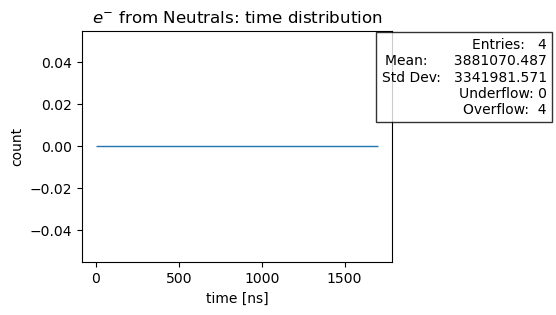

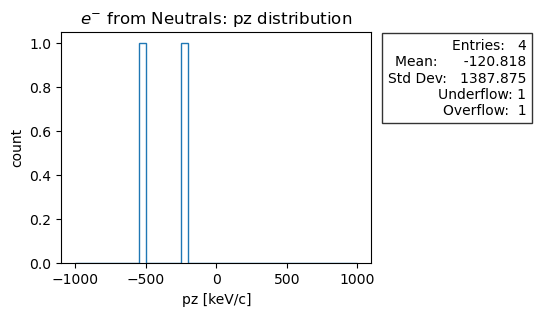

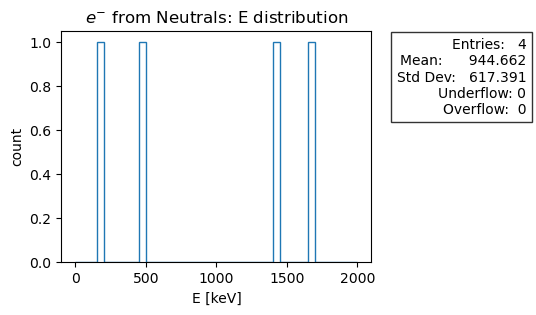

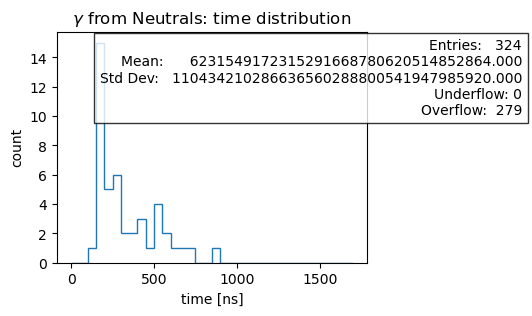

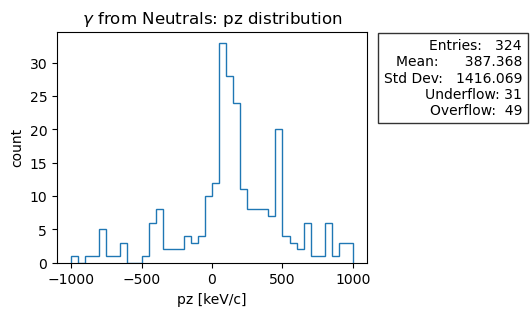

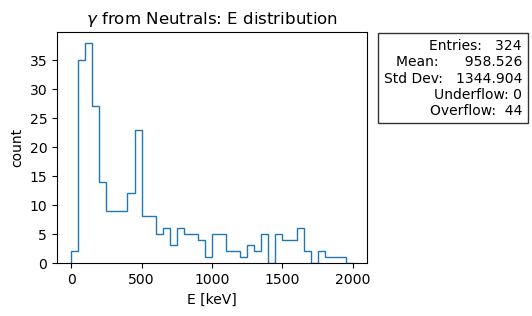

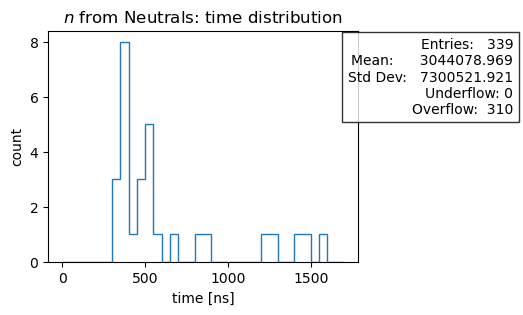

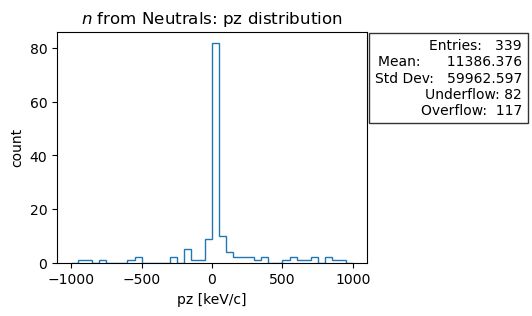

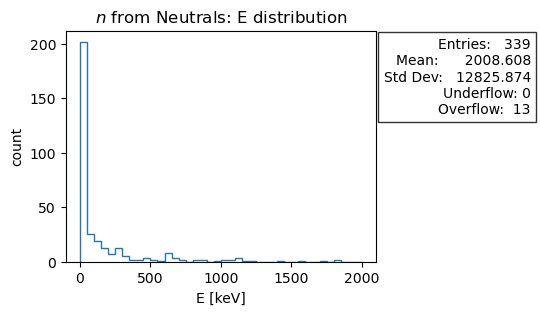

In [4]:
item_list = ['time', 'pz', 'E']
title_list = [item+' distribution' for item in item_list]
xlabel_list = ['time [ns]', 'pz [keV/c]', 'E [keV]']
ylabel_list = ['count' for item in item_list]

for tag in tags:
    print("")
    df_ = df_particles.query("tag==@tag").reset_index()
    list_of_pdgId = np.sort(df_['pdgId'].unique())
    for pdgId in list_of_pdgId:
        mydf = df_.query("pdgId==%i"%(pdgId)).reset_index(drop=True)
        group_name = pdgid_dict[pdgId]+' from '+tag+': '
        print(group_name, len(mydf))
        for index, item in enumerate(item_list):
            fig, ax = plot_utils.single_hist(mydf, item, [group_name+title_list[index], xlabel_list[index], ylabel_list[index]])        

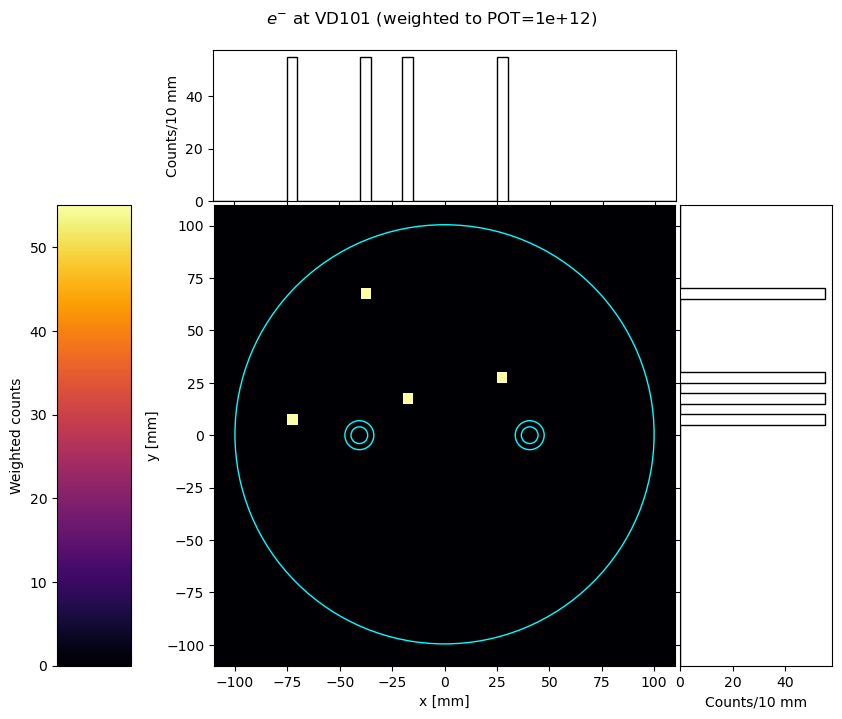

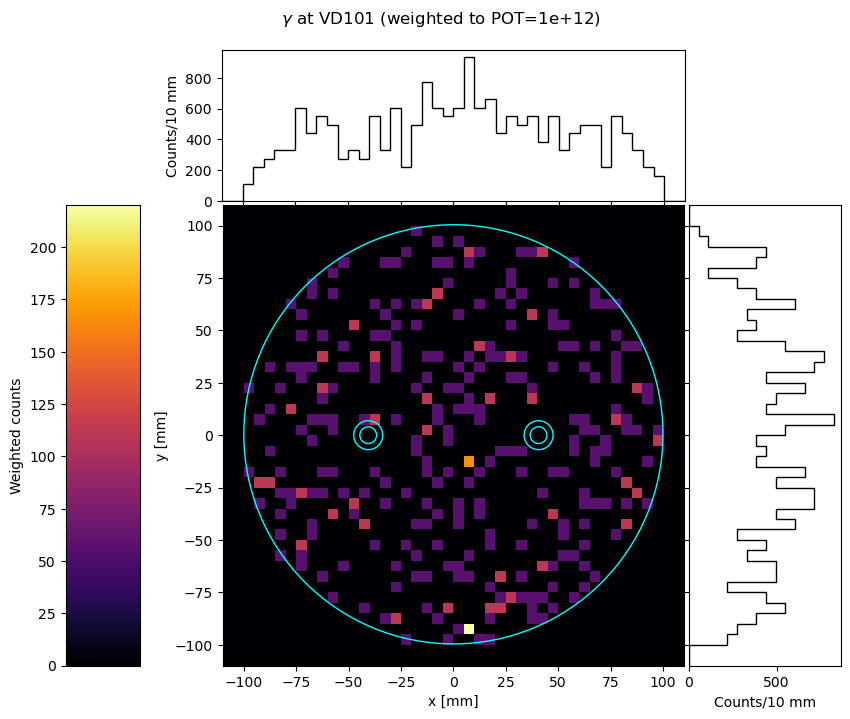

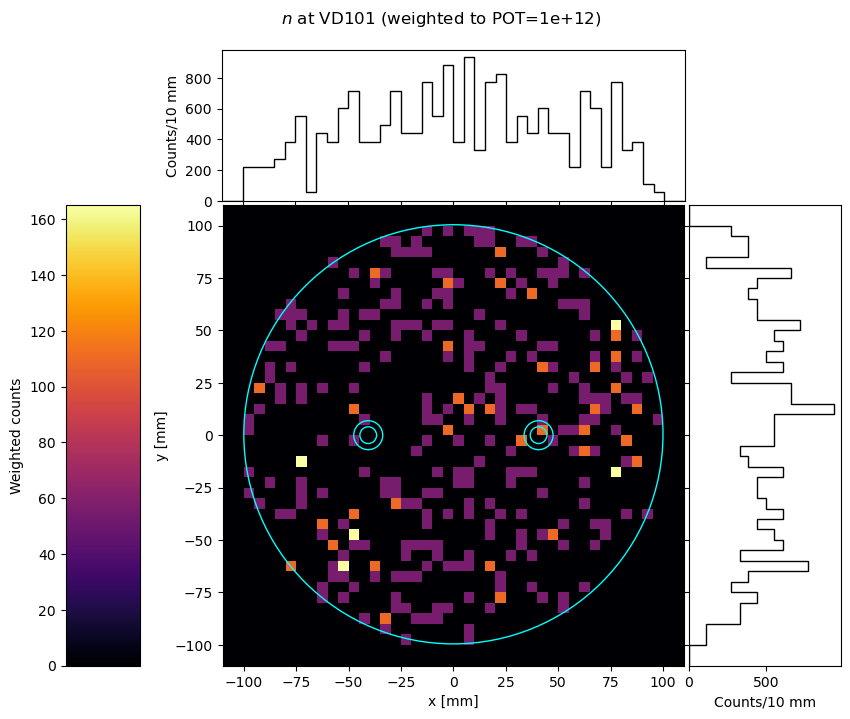

In [5]:
list_of_pdgId = np.sort(df_particles['pdgId'].unique())
for pdgId in list_of_pdgId:
    mydf = df_particles.query("pdgId==%i"%(pdgId)).reset_index()
    fig, ax2d, axX, axY = plot_utils.particle_space_dist(mydf, pdgid_dict[pdgId]+" at VD101 (weighted to POT=%.0e)"%int(filepath.goal_POT)) 
    plt.show()

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          3
index                          73
time                 80711.446877
virtualdetectorId             101
creationCode                   40
pdgId                          11
x                    -3876.909392
y                       25.314799
z                         40185.4
px                     433.867428
py                      21.084026
pz                    -209.684907
startx               -3899.394736
starty                  29.441993
startz               40206.801793
startpx               -392.804444
startpy                185.055405
startpz                709.850609
starttime            80711.296875
E                      191.691012
r                       37.077488
weight                   55.07211
Name: 0, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,1687,Neutrals,3,73,80568.570312,80711.296875,97,22,-3526.780053,2309.084988,...,-3899.394736,29.441993,40206.801793,-4.159187e+00,-25.445756,4.769057e+02,-4.159187e+00,-25.445756,4.769057e+02,4.776022e+02
1,1688,Neutrals,3,73,262.904175,80568.570312,56,2112,-922.664231,104.778958,...,-3526.780053,2309.084988,-2518.389707,-1.579713e+04,91.817670,1.825817e+04,1.079135e+01,33.070557,-1.321521e+01,3.101553e+02
2,1689,Neutrals,3,73,84.255089,264.718933,115,2112,-759.226181,190.480885,...,-931.808477,104.832107,306.730259,2.189222e+04,-4259.047985,1.864839e+04,-1.579713e+04,91.817670,1.825817e+04,4.496595e+02
3,1690,Neutrals,3,73,9.352040,79.256416,14,13,3923.378827,18.660736,...,-759.226181,190.480885,13.201970,-4.578001e+04,18044.826508,4.261340e+04,-0.000000e+00,0.000000,-0.000000e+00,1.844247e+04
4,1691,Neutrals,3,73,-8.021960,9.352040,14,-211,3893.121880,-12.423194,...,3923.378827,18.660736,-4192.250900,-3.035170e+03,-39385.894775,5.721051e+04,-3.125822e+04,-2555.022717,6.204755e+04,1.635717e+04
5,1692,Neutrals,3,73,-8.184053,-8.021960,101,3122,3903.113650,-0.969966,...,3893.121880,-12.423194,-6184.396416,-2.485035e+05,-284851.104736,-2.702267e+05,-2.485035e+05,-284851.104736,-2.702267e+05,9.289703e+04
6,1693,Neutrals,3,73,-8.583173,-8.184053,56,2212,3932.049218,-1.087090,...,3903.113650,-0.969966,-6173.531205,-2.150417e+06,0.000000,-8.624852e+06,-2.102560e+06,81558.082581,-8.432719e+06,8.000000e+06


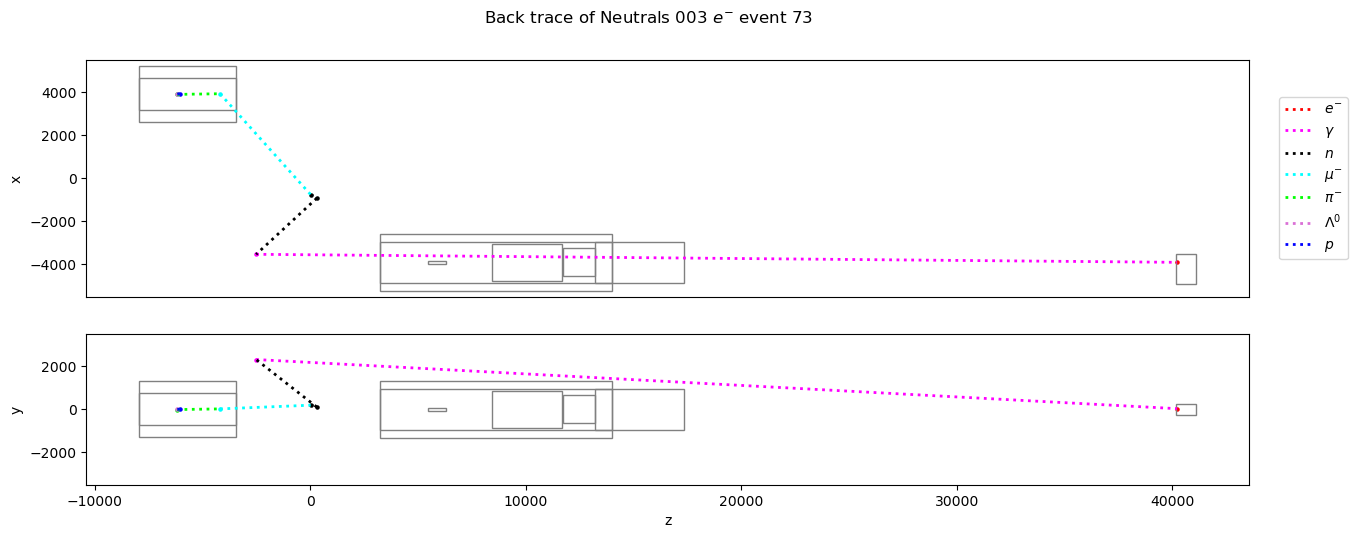

------------------------------------------------------------------------------


tag                         Neutrals
fileno                             0
index                              1
time                 23159725.044468
virtualdetectorId                101
creationCode                      35
pdgId                             22
x                       -3888.711363
y                          -88.26126
z                           40185.38
px                          6.596355
py                         11.502649
pz                        128.026466
startx                  -5118.220791
starty                  -2364.015054
startz                  15326.538439
startpx                   714.344442
startpy                  -421.450794
startpz                 -1005.621314
starttime                 23159642.0
E                           128.7113
r                          89.575624
weight                      55.07211
Name: 0, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,6,Neutrals,0,1,381.121399,2.315964e+07,56,2112,3379.880774,-1325.092282,...,-5118.220791,-2364.015054,15326.538439,-2.018454e+04,-6244.403839,5.802003e+03,4.935748e+00,0.407111,8.184944e-01,2.554406e+02
1,7,Neutrals,0,1,28.057068,5.326876e+02,97,2112,3190.377699,-1104.433104,...,2404.000000,-1626.996314,-4838.225375,-1.292402e+04,29766.496658,4.137074e+02,-2.018454e+04,-6244.403839,5.802003e+03,5.603292e+02
2,8,Neutrals,0,1,27.892891,2.805707e+01,97,2112,3213.981112,-1103.483407,...,3190.377699,-1104.433104,-6999.326679,-5.139511e+05,-11596.106529,4.530850e+04,-5.143328e+05,-41594.013214,3.913215e+02,1.324030e+05
3,9,Neutrals,0,1,24.032616,2.789289e+01,97,2112,3690.141587,-581.172504,...,3213.981112,-1103.483407,-7000.782239,-4.910315e+05,-564456.481934,-3.321567e+05,-5.282268e+05,-560932.983398,-2.762546e+05,3.065623e+05
4,10,Neutrals,0,1,20.139626,2.403262e+01,101,2112,3895.387108,0.382190,...,3690.141587,-581.172504,-6722.562692,-2.289303e+05,-648664.428711,-5.819301e+05,-2.289303e+05,-648664.428711,-5.819301e+05,3.622028e+05
5,11,Neutrals,0,1,19.645338,2.013963e+01,56,2212,3931.595253,-0.241918,...,3895.387108,0.382190,-6200.838100,-2.150417e+06,0.000000,-8.624852e+06,-2.095027e+06,62516.460419,-8.416834e+06,8.000000e+06


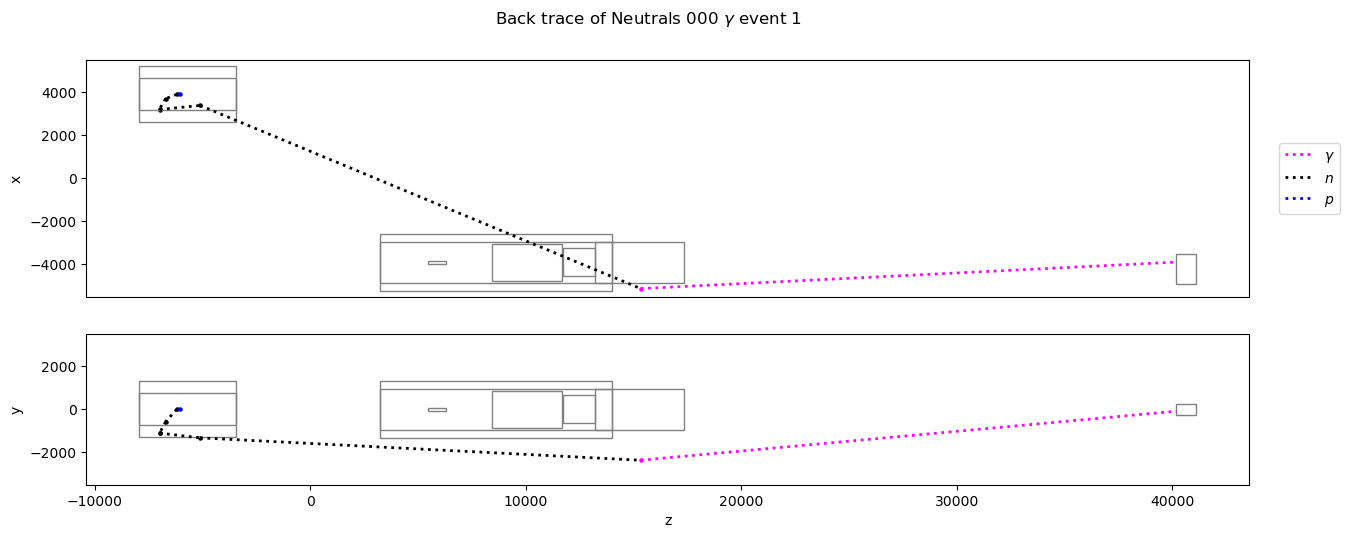

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          0
index                          36
time                 50896.330033
virtualdetectorId             101
creationCode                   35
pdgId                          22
x                    -3911.648728
y                       67.926023
z                        40185.38
px                     -12.124074
py                     -12.351485
pz                     127.052169
startx                -1600.50059
starty               -2350.052944
startz                1848.522238
startpx                 156.28539
startpy                550.512314
startpz               -330.002308
starttime            50760.898438
E                      128.225606
r                       68.355305
weight                   55.07211
Name: 20, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,226,Neutrals,0,36,128.437454,50760.898438,97,2112,1386.507651,-205.835264,...,-1600.500590,-2350.052944,1848.522238,-1.913157e+04,-28210.111618,-5.640318e+03,-7.185813e+00,47.284015,1.716918e+01,6.349942e+02
1,227,Neutrals,0,36,72.186546,128.437454,56,2112,1000.576412,20.671117,...,1386.507651,-205.835264,-809.091278,-1.094384e+04,30683.147430,-4.708375e+04,3.572800e+04,-33016.273499,-2.190927e+04,1.742862e+03
2,228,Neutrals,0,36,49.680393,72.822945,97,2112,1108.376667,253.294031,...,998.358258,26.890136,-323.137414,-1.581366e+04,-44377.716064,-3.417059e+04,-1.094384e+04,30683.147430,-4.708375e+04,1.800747e+03
3,229,Neutrals,0,36,49.337749,49.680393,78,2112,1106.394161,246.278213,...,1108.376667,253.294031,-53.975340,1.818629e+04,64358.802795,-2.556933e+04,1.818629e+04,64358.802795,-2.556933e+04,2.724220e+03
4,230,Neutrals,0,36,-13.860038,49.337749,14,-211,3904.027641,-34.779903,...,1106.394161,246.278213,-51.188002,4.510696e+04,57219.165802,5.070580e+04,-0.000000e+00,0.000000,-0.000000e+00,2.583715e+04
5,231,Neutrals,0,36,-14.449372,-13.860038,101,3122,3878.485050,0.681962,...,3904.027641,-34.779903,-6255.476869,1.671198e+05,-232019.561768,9.872309e+04,1.671198e+05,-232019.561768,9.872309e+04,4.028290e+04
6,232,Neutrals,0,36,-15.184392,-14.449372,56,2212,3931.128614,0.132469,...,3878.485050,0.681962,-6270.565704,-2.150417e+06,0.000000,-8.624852e+06,-1.967006e+06,88907.440186,-8.302497e+06,8.000000e+06


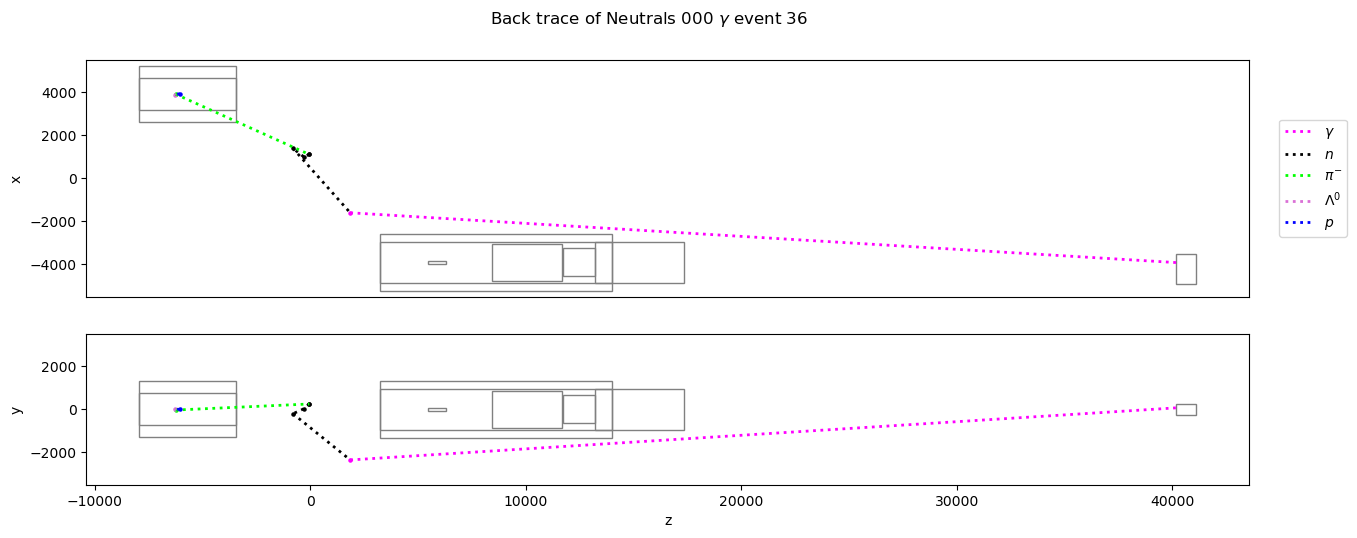

------------------------------------------------------------------------------


tag                                                 Neutrals
fileno                                                     1
index                                                     18
time                 1990777608976918968687466130576506880.0
virtualdetectorId                                        101
creationCode                                              56
pdgId                                                     22
x                                               -3853.945237
y                                                 -43.195366
z                                                   40185.38
px                                                 -4.331279
py                                                 -3.344813
pz                                                  45.59546
startx                                           4080.905077
starty                                               -2312.0
startz                                            943.476544
startpx                 

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,521,Neutrals,1,18,1.990778e+36,1.990778e+36,133,22,4086.683891,-2337.705465,...,545.366231,1549.150000,756.323456,-4.937420e+01,-120.258026,1.566619e+01,-5.932712e+01,64.790949,-3.140470e+00,1.309398e+02
1,522,Neutrals,1,18,1.990778e+36,1.990778e+36,133,1000210489,4086.683891,-2337.705465,...,4086.683891,-2337.705465,918.553593,7.741304e+01,75.528763,-5.516281e+01,0.000000e+00,0.000000,-0.000000e+00,1.378066e-04
2,523,Neutrals,1,18,1.990778e+36,1.990778e+36,133,1000210489,4086.683891,-2337.705465,...,4086.683891,-2337.705465,918.553593,1.932020e+00,-33.623770,1.286048e+01,0.000000e+00,-0.000000,0.000000e+00,1.215085e-05
3,524,Neutrals,1,18,1.387250e+05,1.990778e+36,58,1000200480,4086.683891,-2337.705465,...,4086.683891,-2337.705465,918.553593,-1.700070e+01,40.983301,-3.432654e+01,-0.000000e+00,0.000000,-0.000000e+00,3.523019e-05
4,525,Neutrals,1,18,1.096791e+01,1.466384e+06,97,2112,4090.514573,-38.939955,...,2503.025825,307.513431,2056.950000,-3.296016e+04,20316.150665,-1.755350e+04,-3.754259e+00,6.262933,2.763149e+00,9.612527e+02
5,526,Neutrals,1,18,1.092593e+01,1.096791e+01,97,2112,4091.440080,-39.542464,...,4090.514573,-38.939955,-3864.924294,-6.936098e+04,45154.342651,9.542909e+02,-6.936098e+04,45154.342651,9.542909e+02,3.638667e+03
6,527,Neutrals,1,18,9.209667e+00,1.092593e+01,78,2112,4017.628035,-104.370093,...,4091.440080,-39.542464,-3864.937028,1.375945e+05,120846.511841,6.012239e+04,1.375945e+05,120846.511841,6.012239e+04,1.956649e+04
7,528,Neutrals,1,18,-2.017854e+01,9.209667e+00,14,-211,3931.384516,-0.112858,...,4017.628035,-104.370093,-3897.189446,-3.702814e+04,-61810.379028,2.656700e+04,0.000000e+00,0.000000,0.000000e+00,1.973220e+04
8,529,Neutrals,1,18,-2.041001e+01,-2.017854e+01,101,3122,3922.900671,0.836138,...,3931.384516,-0.112858,-6104.657250,1.398257e+05,-15640.788078,-2.084157e+05,1.398257e+05,-15640.788078,-2.084157e+05,2.798727e+04
9,530,Neutrals,1,18,-2.052772e+01,-2.041001e+01,56,2212,3931.420943,0.839648,...,3922.900671,0.836138,-6092.011738,-2.150417e+06,0.000000,-8.624852e+06,-2.172135e+06,26.727732,-8.562731e+06,8.000000e+06


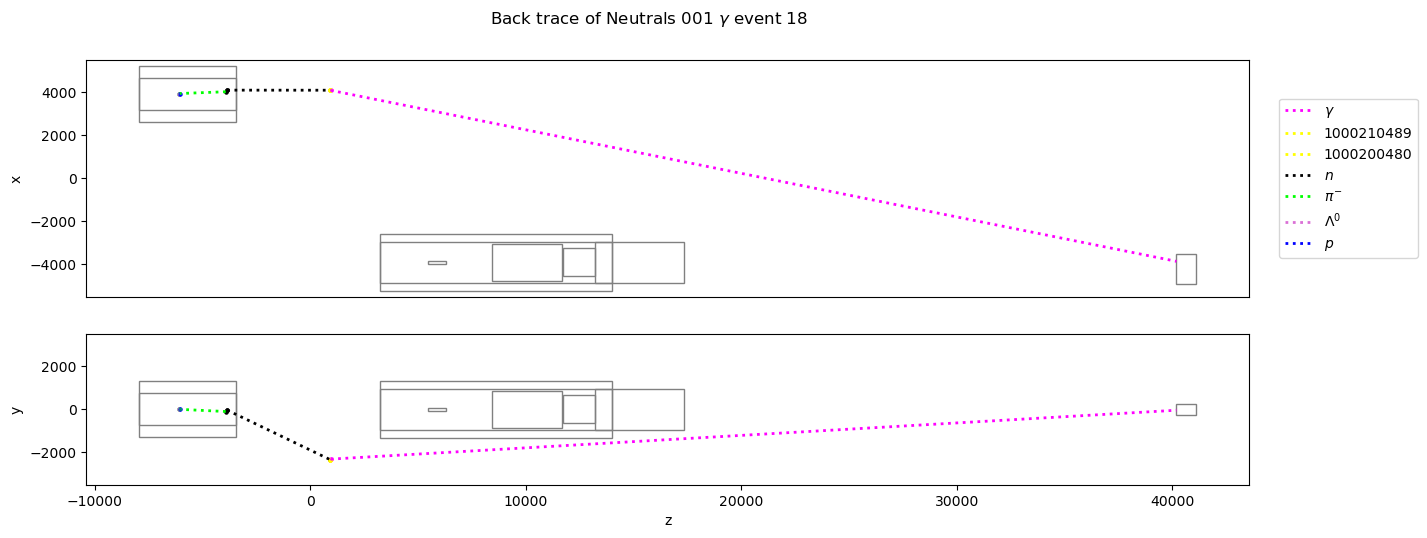

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          1
index                          47
time                 17513.737878
virtualdetectorId             101
creationCode                   56
pdgId                          22
x                    -3877.905582
y                       36.666885
z                        40185.38
px                      -4.238311
py                      -6.887756
pz                     141.154302
startx                     5404.0
starty                1057.298378
startz               -3890.083116
startpx               -906.514466
startpy                 42.866457
startpz                696.406603
starttime               17331.375
E                       141.38579
r                       45.004212
weight                   55.07211
Name: 60, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,691,Neutrals,1,47,17330.990234,17358.841797,35,22,5491.834981,1052.679929,...,-1121.350000,1365.863380,1122.850543,-5.730742e+02,159.561276,1.848258e+03,-9.065145e+02,42.866457,6.964066e+02,1.941631e+03
1,692,Neutrals,1,47,128.539581,17330.990234,97,2112,3684.513364,-103.196126,...,5491.834981,1052.679929,-3962.502674,-3.826030e+03,14643.081665,1.688976e+04,4.792308e+00,-11.743027,-2.852988e+00,2.736624e+02
2,693,Neutrals,1,47,67.881668,128.539581,97,2112,3948.196493,287.216772,...,3684.513364,-103.196126,-6731.530707,3.134091e+04,-20100.484848,4.190252e+04,-1.496750e+04,-13009.606361,-4.583337e+04,1.670619e+03
3,694,Neutrals,1,47,67.575081,67.881668,101,2112,3929.580490,287.570927,...,3948.196493,287.216772,-6688.896000,1.522293e+05,-80154.624939,1.778183e+05,2.013144e+05,4087.725163,1.423286e+05,3.203174e+04
4,695,Neutrals,1,47,65.435837,67.575081,101,2212,3889.255098,0.228293,...,3929.580490,287.570927,-6702.674801,-6.276245e+04,909553.466797,-1.476455e+06,2.511620e+05,664109.619141,-1.282474e+06,1.034417e+06
5,696,Neutrals,1,47,64.861465,65.435837,56,2212,3930.605189,-1.502801,...,3889.255098,0.228293,-6223.899217,-2.150417e+06,0.000000,-8.624852e+06,-2.106911e+06,152078.445435,-8.360352e+06,8.000000e+06


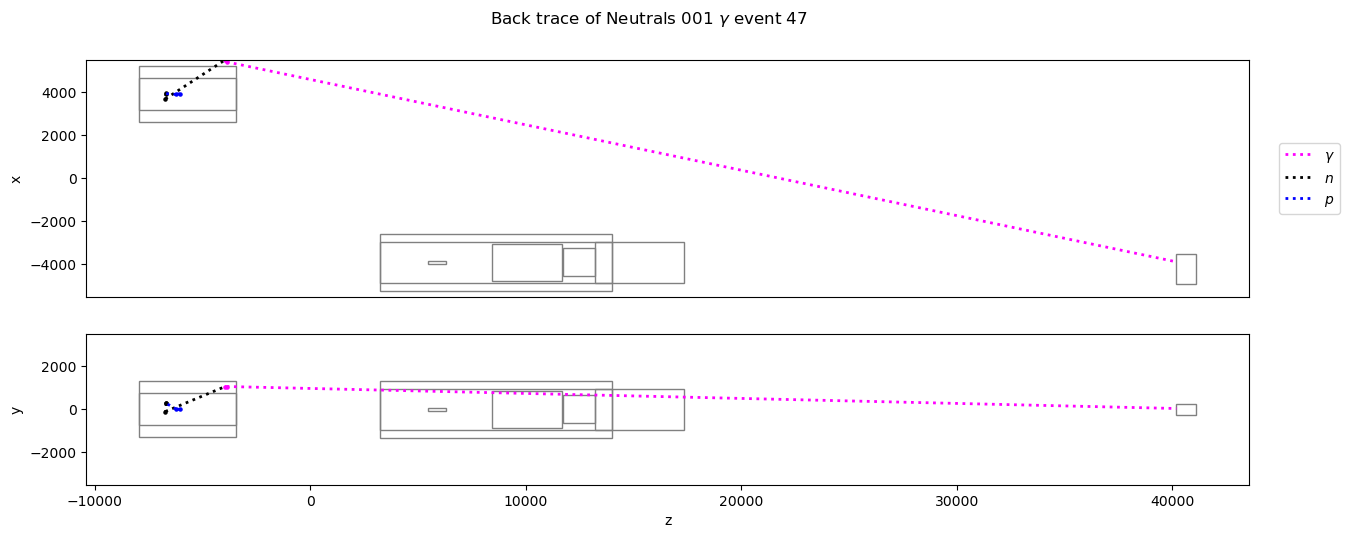

------------------------------------------------------------------------------


tag                     Neutrals
fileno                         2
index                         18
time                  151.078128
virtualdetectorId            101
creationCode                  56
pdgId                         22
x                   -3928.618737
y                     -51.933364
z                       40185.38
px                     -9.142251
py                      2.578737
pz                     71.173723
startx               1983.696816
starty                311.403702
startz               -223.360354
startpx             -5619.006634
startpy               1556.28562
startpz              -395.076811
starttime              -13.97343
E                      71.804801
r                      57.473094
weight                  55.07211
Name: 80, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,942,Neutrals,2,18,-14.766129,-13.869900,16,22,2212.057766,247.694927,...,1953.853878,319.669244,-225.458634,-6.342776e+03,1856.139541,5.002256e+02,-5.619007e+03,1556.285620,-3.950768e+02,6.627691e+03
1,943,Neutrals,2,18,-14.767183,-14.668886,12,11,2212.357902,247.599576,...,2186.726633,257.503196,-205.865073,-5.248019e+04,18004.043579,5.300129e+03,7.210634e+02,-179.834381,4.526902e+01,5.522649e+04
2,944,Neutrals,2,18,-14.791950,-14.196444,16,22,2219.410826,245.329902,...,2142.679256,309.286012,-348.968456,-5.642289e+04,18157.228470,3.931676e+03,-3.701239e+02,418.007702,-8.187801e+02,5.940274e+04
3,945,Neutrals,2,18,-38.097626,-14.734285,13,11,3908.072489,0.291317,...,2204.837306,251.261510,-214.124419,-7.630121e+04,-13530.904770,1.765531e+05,5.309734e+02,-476.559430,8.388009e+02,1.923003e+05
4,946,Neutrals,2,18,-38.097839,-38.097626,14,22,3908.097363,0.296205,...,3908.072489,0.291317,-6143.891449,-8.270915e+04,-16254.953384,1.927919e+05,-8.270915e+04,-16254.953384,1.927919e+05,2.104133e+05
5,947,Neutrals,2,18,-38.097839,-38.097839,95,111,3908.097371,0.296205,...,3908.097363,0.296205,-6143.949429,-7.936553e+04,1871.234775,1.758377e+05,-7.936553e+04,1871.234775,1.758377e+05,1.004803e+05
6,948,Neutrals,2,18,-38.176529,-38.097839,101,310,3914.105590,1.163043,...,3908.097371,0.296205,-6143.949446,-2.675688e+05,-38603.569031,-8.848644e+05,-2.675688e+05,-38603.569031,-8.848644e+05,5.529516e+05
7,949,Neutrals,2,18,-38.405758,-38.176529,56,2212,3931.043760,0.984670,...,3914.105590,1.163043,-6124.079936,-2.150417e+06,0.000000,-8.624852e+06,-2.237169e+06,1395.984173,-8.505072e+06,8.000000e+06


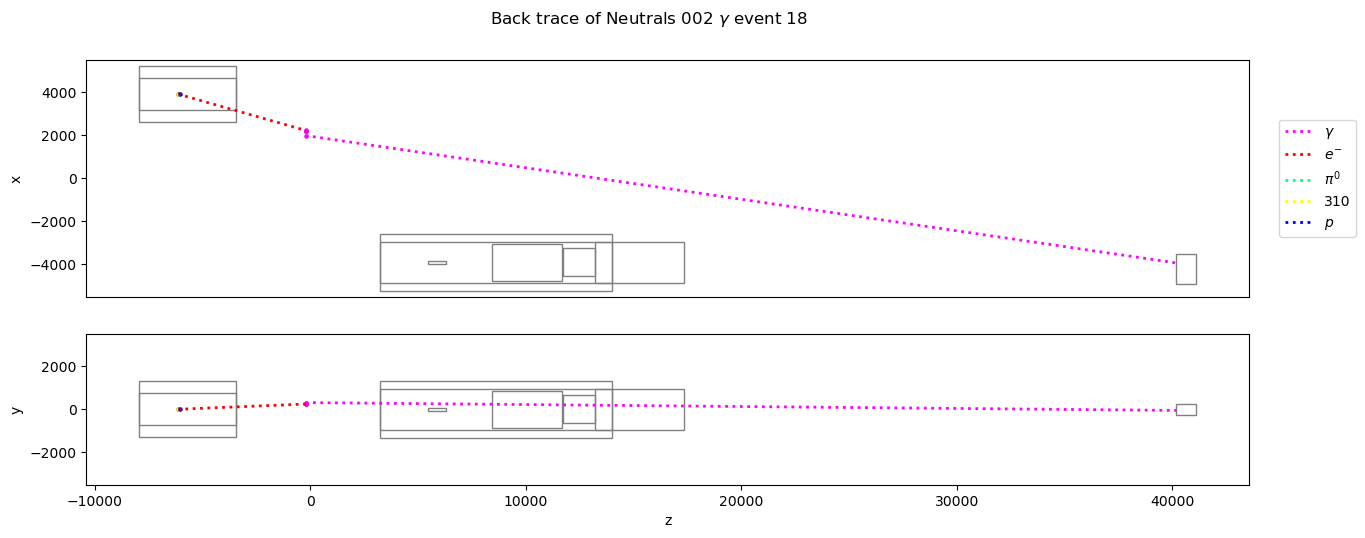

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           2
index                           66
time                 5824805.74726
virtualdetectorId              101
creationCode                    35
pdgId                           22
x                     -3924.455546
y                       -97.239367
z                         40185.38
px                      -53.072064
py                       74.106906
pz                      203.502789
startx                -2335.657843
starty                -2314.434735
startz                34096.027376
startpx                  -402.7659
startpy                -223.631591
startpz                -148.897201
starttime                5824783.5
E                       222.983996
r                         99.36762
weight                    55.07211
Name: 100, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,1227,Neutrals,2,66,1191.355957,5.824784e+06,56,2112,2742.633696,680.754635,...,-2335.657843,-2314.434735,34096.027376,-2.107203e+03,3907.487631,6.435980e+02,4.338046e-01,-3.203817,3.046787e+00,1.070860e+01
1,1228,Neutrals,2,66,-0.158613,1.195302e+03,115,2112,3046.636152,247.802461,...,2739.980918,685.673809,-940.913403,-4.227805e+04,9840.081215,-3.386252e+04,-2.107203e+03,3907.487631,6.435980e+02,1.611561e+03
2,1229,Neutrals,2,66,-70.000885,-1.813111e+01,14,13,3967.324221,78.956443,...,3046.636152,247.802461,-805.446553,-4.907293e+04,68288.375854,1.728671e+04,-0.000000e+00,0.000000,-0.000000e+00,3.048118e+04
3,1230,Neutrals,2,66,-70.864449,-7.000089e+01,101,-211,3924.591777,0.274090,...,3967.324221,78.956443,-6054.930731,7.304939e+04,4911.728382,4.895446e+04,-3.642049e+04,54715.007782,1.430176e+04,2.546531e+04
4,1231,Neutrals,2,66,-70.937355,-7.086445e+01,56,2212,3929.866175,0.223625,...,3924.591777,0.274090,-6078.666440,-2.150417e+06,0.000000,-8.624852e+06,-2.142323e+06,20441.680908,-8.592928e+06,8.000000e+06


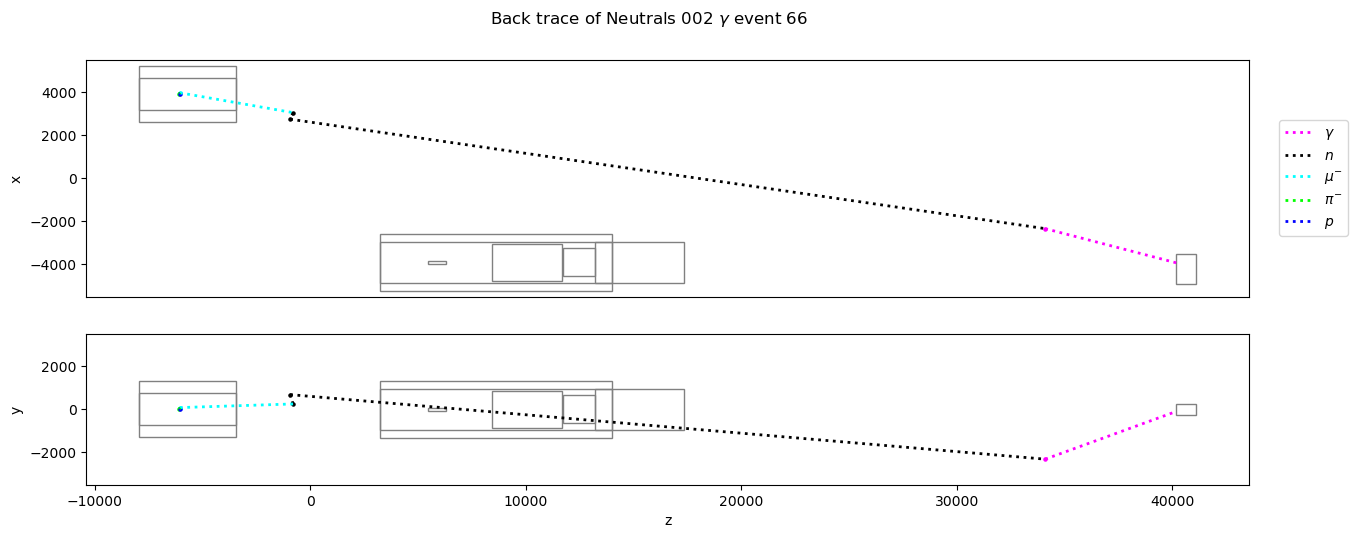

------------------------------------------------------------------------------


tag                              Neutrals
fileno                                  3
index                                  44
time                 36060150105639.03125
virtualdetectorId                     101
creationCode                           74
pdgId                                  22
x                            -3963.168392
y                               68.706076
z                                40185.38
px                            -320.661452
py                            -147.928444
pz                             2731.31278
startx                         -54.770186
starty                        1871.739343
startz                        6894.637073
startpx                       -320.661455
startpy                       -147.928447
startpz                       2731.312752
starttime                36060151152640.0
E                             2754.047221
r                               90.672065
weight                           55.07211
Name: 120, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,1511,Neutrals,3,44,3.606015e+13,3.606015e+13,74,1000120249,-54.770186,1871.739343,...,-54.770186,1871.739343,6894.637073,2.186258e+02,-1000.653267,-1.203318e+03,0.000000e+00,-0.000000,-0.000000e+00,4.032360e-02
1,1512,Neutrals,3,44,1.333378e+05,1.333378e+05,35,1000110240,-54.770186,1871.739342,...,-54.770186,1871.739343,6894.637073,4.614015e+03,3379.998207,-4.054453e+03,0.000000e+00,0.000000,-0.000000e+00,1.100003e+00
2,1513,Neutrals,3,44,1.676462e+03,1.333378e+05,56,2112,4236.042730,1560.637368,...,-54.770186,1871.739342,6894.637073,-1.446769e+03,-257.469475,1.720401e+03,3.979239e-01,-2.561444,1.188782e+00,2.724239e+00
3,1514,Neutrals,3,44,3.803023e+01,9.970501e+03,97,2112,3566.535638,-143.214241,...,407.287353,879.265310,1373.900000,4.495593e+04,11552.250862,-8.184717e+03,-1.446769e+03,-257.469475,1.720401e+03,1.181442e+03
4,1515,Neutrals,3,44,3.513436e+01,3.803023e+01,97,2112,3588.015331,-135.995845,...,3566.535638,-143.214241,-6120.790106,-1.844158e+04,-9137.918472,6.344804e+04,-6.483922e+04,3325.093031,3.801061e+03,2.364740e+03
5,1516,Neutrals,3,44,3.413515e+01,3.513436e+01,97,2112,3563.954613,-143.090618,...,3588.015331,-135.995845,-6173.507694,7.574384e+04,22334.550858,1.604058e+04,7.574384e+04,22334.550858,1.604058e+04,3.449130e+03
6,1517,Neutrals,3,44,3.187959e+01,3.413515e+01,101,2112,3925.053390,0.606605,...,3563.954613,-143.090618,-6178.603130,-6.230532e+05,-248031.250000,-1.645322e+05,-6.232215e+05,-211100.189209,-2.089524e+05,2.264401e+05
7,1518,Neutrals,3,44,3.179520e+01,3.187959e+01,56,2212,3931.153096,0.621226,...,3925.053390,0.606605,-6082.310233,-2.150417e+06,0.000000,-8.624852e+06,-2.153302e+06,-6429.697037,-8.591374e+06,8.000000e+06


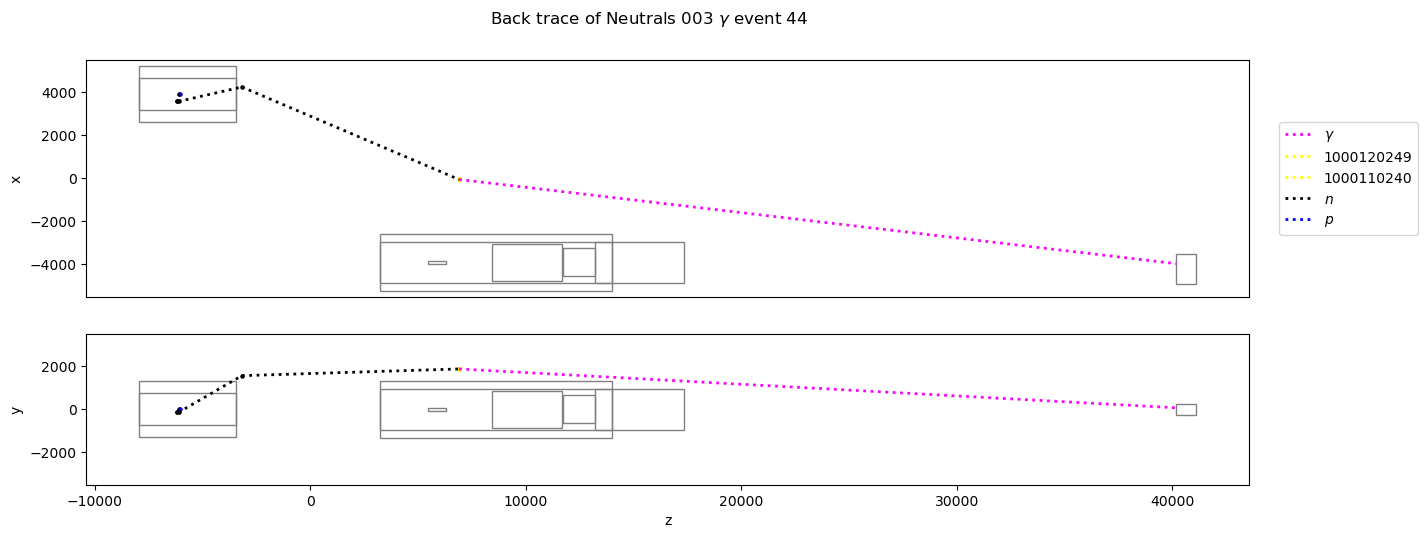

------------------------------------------------------------------------------


tag                     Neutrals
fileno                         4
index                         13
time                  202.507261
virtualdetectorId            101
creationCode                  16
pdgId                         22
x                   -3911.438774
y                      35.673095
z                       40185.38
px                      35.81373
py                     76.898682
pz                     23.507872
startx                -78.960384
starty               1299.342436
startz              -1054.771938
startpx             -2107.669592
startpy              -134.668678
startpz              -203.977063
starttime              63.899059
E                       88.02642
r                      36.440432
weight                  55.07211
Name: 140, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,1756,Neutrals,4,13,63.896618,63.917686,12,11,-78.251085,1299.148841,...,-82.108586,1302.006954,-1052.468212,-5.171109e+03,1978.307724,-7.333491e+02,-0.000000e+00,-0.000000,0.000000e+00,5.097298e+03
1,1757,Neutrals,4,13,54.530560,75.791695,56,22,2493.374802,300.685914,...,368.481411,733.141981,612.755143,-4.981278e+03,1934.037685,-1.013870e+03,1.174645e+01,50.667346,3.469374e+01,5.438894e+03
2,1758,Neutrals,4,13,54.068447,54.592896,16,22,2620.256821,251.422531,...,2476.259110,307.331276,-534.803704,-4.981278e+03,1934.037685,-1.013870e+03,-4.981278e+03,1934.037685,-1.013870e+03,5.438894e+03
3,1759,Neutrals,4,13,12.796638,54.145893,13,11,3930.505913,1.820844,...,2600.517525,260.469150,-502.049627,8.317581e+04,79482.612610,2.151348e+02,3.882200e+02,6.977773,-1.079864e+03,1.145369e+05
4,1760,Neutrals,4,13,12.790949,12.796638,14,22,3929.275238,0.639929,...,3930.505913,1.820844,-6066.286699,1.360807e+05,130578.613281,7.159070e+02,1.360807e+05,130578.613281,7.159070e+02,1.885981e+05
5,1761,Neutrals,4,13,12.790949,12.790949,101,111,3929.275231,0.639925,...,3929.275238,0.639929,-6066.293173,1.902825e+05,96786.109924,-3.266647e+03,1.902825e+05,96786.109924,-3.266647e+03,1.176186e+05
6,1762,Neutrals,4,13,12.762117,12.790949,56,2212,3931.360803,0.641335,...,3929.275231,0.639925,-6066.293173,-2.150417e+06,0.000000,-8.624852e+06,-2.167058e+06,-13786.332130,-8.607203e+06,8.000000e+06


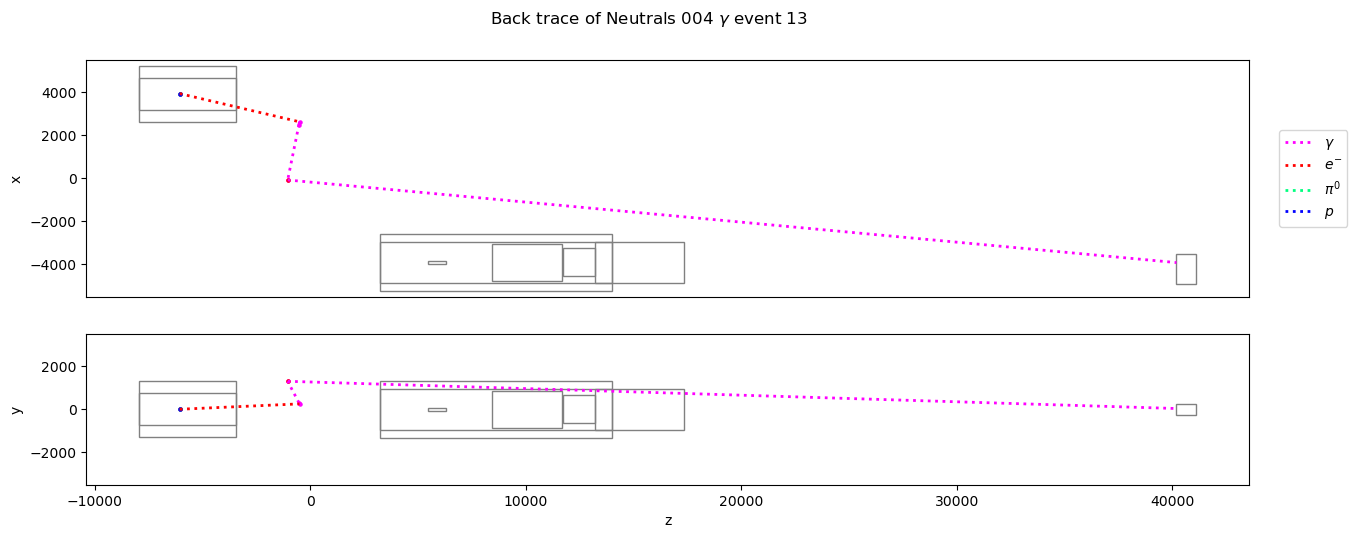

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          4
index                          50
time                 21318.018778
virtualdetectorId             101
creationCode                   97
pdgId                          22
x                    -3960.435296
y                      -18.108331
z                        40185.38
px                     -71.639878
py                      57.800615
pz                     388.400267
startx                -395.523958
starty                2535.974561
startz                2266.585385
startpx               -245.342314
startpy               -144.191861
startpz                383.560091
starttime            21188.333984
E                      399.159054
r                       59.269337
weight                   55.07211
Name: 160, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,1976,Neutrals,4,50,19.118942,21188.333984,97,2112,1453.633947,-216.151727,...,-395.523958,2535.974561,2266.585385,1.653115e+04,23220.823288,-2.129336e+04,8.229111e+00,22.603240,4.298165e+00,6.734174e+02
1,1977,Neutrals,4,50,16.955227,19.118942,97,2112,1363.359938,-238.093456,...,1453.633947,-216.151727,454.228859,1.321656e+05,32123.783112,2.465135e+04,1.321656e+05,32123.783112,2.465135e+04,1.011377e+04
2,1978,Neutrals,4,50,10.426155,16.955227,56,2112,1157.079597,-61.786448,...,1363.359938,-238.093456,437.391080,1.002247e+05,-85661.674500,6.535002e+04,1.002247e+05,-85661.674500,6.535002e+04,1.145336e+04
3,1979,Neutrals,4,50,0.671554,10.789222,78,2112,848.891436,201.620779,...,1168.550422,-71.590517,310.368456,1.002247e+05,-85661.674500,6.535002e+04,1.002247e+05,-85661.674500,6.535002e+04,1.145336e+04
4,1980,Neutrals,4,50,-63.926727,0.671554,101,-211,3903.285018,-1.554600,...,848.891436,201.620779,101.939608,2.579820e+04,-65580.635071,6.580733e+04,-0.000000e+00,0.000000,-0.000000e+00,3.006710e+04
5,1981,Neutrals,4,50,-64.278008,-63.926727,56,2212,3929.752159,-1.567539,...,3903.285018,-1.554600,-6158.872874,-2.150417e+06,0.000000,-8.624852e+06,-2.210183e+06,16765.501022,-8.442896e+06,8.000000e+06


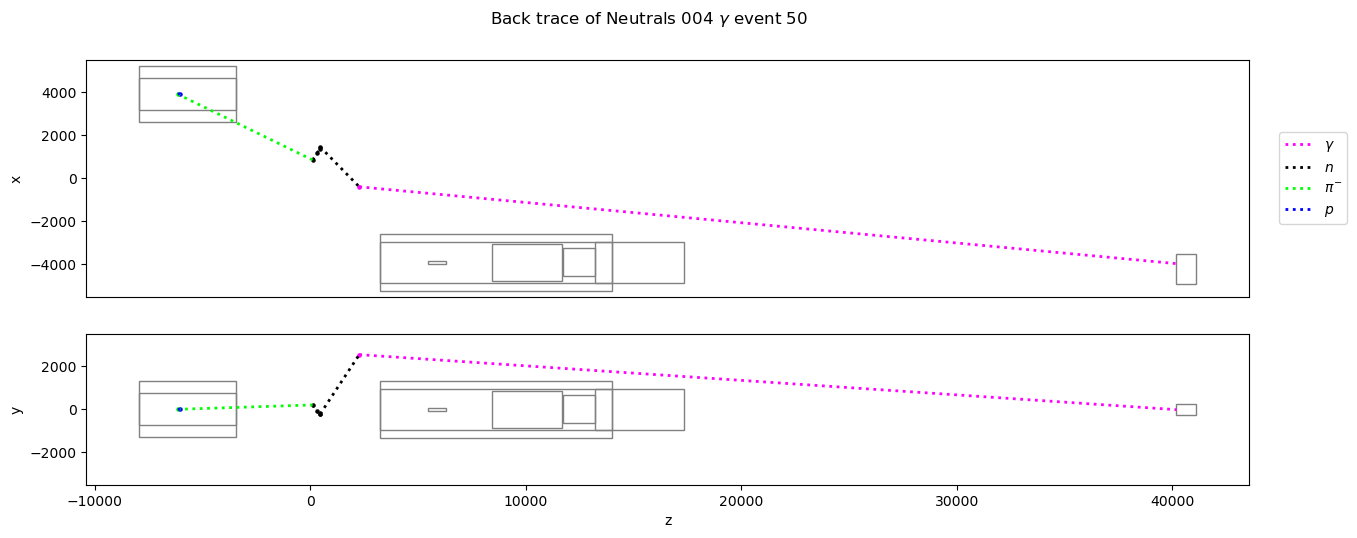

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           5
index                           15
time                 670611.191244
virtualdetectorId              101
creationCode                    97
pdgId                           22
x                     -3904.577148
y                       -96.410519
z                         40185.38
px                       70.415321
py                      -91.584803
pz                       81.335025
startx                -4253.555808
starty                 2379.349528
startz                -2248.338548
startpx                -367.441505
startpy                 261.907041
startpz                 -156.51539
starttime                 670462.5
E                       141.285101
r                        96.412247
weight                    55.07211
Name: 180, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,2196,Neutrals,5,15,21501.363281,670462.500000,56,2112,3658.936105,2869.600000,...,-4253.555808,2379.349528,-2248.338548,-6.102243e+02,-1678.501725,1.741436e+03,-2.696089e+01,8.821505,-1.849799e+01,3.311282e+00
1,2197,Neutrals,5,15,81.767029,26034.769531,97,2112,1285.018097,505.822923,...,2776.250000,441.656364,2368.936874,1.127685e+04,-18873.659134,5.200705e+04,-6.102243e+02,-1678.501725,1.741436e+03,1.695061e+03
2,2198,Neutrals,5,15,81.603615,81.767029,101,2112,1291.498325,498.834057,...,1285.018097,505.822923,-18063.026974,-1.287588e+05,138865.188599,1.698862e+05,-1.287588e+05,138865.188599,1.698862e+05,3.383423e+04
3,2199,Neutrals,5,15,40.292870,81.603615,56,2212,3932.246270,-1.281628,...,1291.498325,498.834057,-18071.577079,-2.150417e+06,0.000000,-8.624852e+06,-1.837318e+06,348660.003662,-8.290455e+06,8.000000e+06


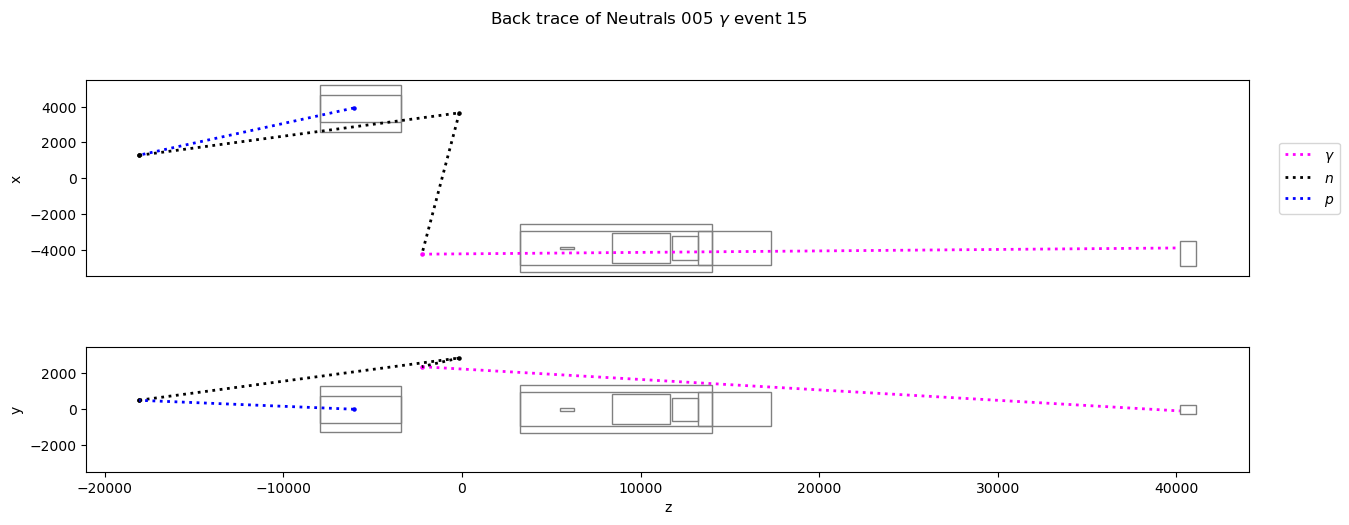

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           6
index                            2
time                 226108.005945
virtualdetectorId              101
creationCode                    35
pdgId                           22
x                     -3944.824073
y                         6.649045
z                         40185.38
px                        22.78525
py                     -197.023915
pz                      267.702448
startx                -3946.110143
starty                   17.769682
startz                40170.270049
startpx                   22.78525
startpy                -197.023913
startpz                  267.70246
starttime              226107.9375
E                       333.169913
r                        41.361997
weight                    55.07211
Name: 200, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,2554,Neutrals,6,2,206.504196,226107.937500,97,2112,900.494532,786.750457,...,-3946.110143,17.769682,40170.270049,-2.169652e+04,-9901.393890,8.386850e+03,2.721923e+00,-3.912881,3.782209e+00,3.400510e+02
1,2555,Neutrals,6,2,173.902313,206.504196,56,2112,816.854859,313.202687,...,900.494532,786.750457,156.356099,8.050856e+03,45582.012177,1.270371e+04,8.050856e+03,45582.012177,1.270371e+04,1.225258e+03
2,2556,Neutrals,6,2,162.265640,174.577789,97,2112,785.308093,225.168554,...,818.587789,323.014123,27.112710,4.139589e+04,26321.990967,1.448107e+04,8.050856e+03,45582.012177,1.270371e+04,1.391193e+03
3,2557,Neutrals,6,2,160.619278,162.265640,115,2112,810.569477,190.309583,...,785.308093,225.168554,-16.283243,-4.848677e+04,66908.409119,-8.874704e+04,-4.848677e+04,66908.409119,-8.874704e+04,7.792442e+03
4,2558,Neutrals,6,2,3.845306,104.611526,14,13,3890.322015,77.279513,...,810.569477,190.309583,29.953553,3.887026e+03,-29846.130371,2.330815e+04,-0.000000e+00,0.000000,0.000000e+00,6.648626e+03
5,2559,Neutrals,6,2,1.792190,3.845306,101,-211,3920.980103,-0.841841,...,3890.322015,77.279513,-5991.124650,6.408014e+04,81408.317566,-7.631496e+04,-1.966528e+04,-72297.470093,3.340094e+04,5.026498e+04
6,2560,Neutrals,6,2,1.644424,1.792190,56,2212,3931.488349,-0.945223,...,3920.980103,-0.841841,-6100.765043,-2.150417e+06,0.000000,-8.624852e+06,-2.099611e+06,17741.191864,-8.500186e+06,8.000000e+06


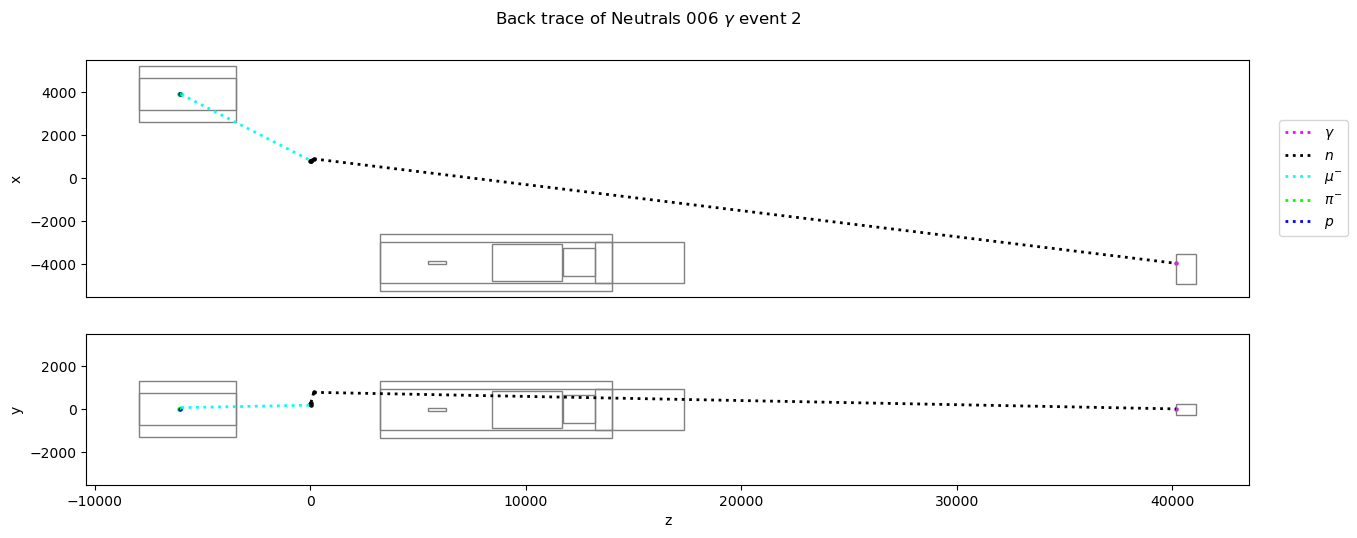

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          6
index                          43
time                 20625.912963
virtualdetectorId             101
creationCode                   97
pdgId                          22
x                    -3882.066623
y                        37.88699
z                        40185.38
px                     118.560835
py                      34.081539
pz                     199.576967
startx                -3199.63275
starty                2525.230962
startz                2109.178797
startpx               -448.840141
startpy               -161.935791
startpz                -20.592887
starttime            20498.455078
E                      234.625635
r                       43.777815
weight                   55.07211
Name: 220, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,2792,Neutrals,6,43,1583.958252,20498.455078,56,2112,7218.642750,461.705870,...,-3199.632750,2525.230962,2109.178797,-2.696937e+03,395.254970,1.036176e+03,6.608010e+00,-9.622424,3.778992e-01,4.525143e+00
1,2793,Neutrals,6,43,-3.367051,10206.553711,97,2112,3766.386790,102.972948,...,-201.297093,1549.150000,908.173489,-2.208621e+03,39434.436798,-3.531397e+03,-2.696937e+03,395.254970,1.036176e+03,8.364101e+02
2,2794,Neutrals,6,43,-9.370596,-3.367051,78,2112,4028.091949,95.038216,...,3766.386790,102.972948,-3160.379913,-2.548042e+03,-30784.879684,2.194508e+05,-8.474438e+04,8035.172462,1.976231e+05,2.578220e+04
3,2795,Neutrals,6,43,-23.317677,-9.370596,101,-211,3931.399907,0.706515,...,4028.091949,95.038216,-3462.762781,4.257471e+04,-43797.752380,1.251631e+05,-0.000000e+00,0.000000,0.000000e+00,5.760101e+04
4,2796,Neutrals,6,43,-23.321018,-23.317677,56,2212,3931.642116,0.707686,...,3931.399907,0.706515,-6058.990969,-2.150417e+06,0.000000,-8.624852e+06,-2.162524e+06,-6136.637211,-8.619050e+06,8.000000e+06


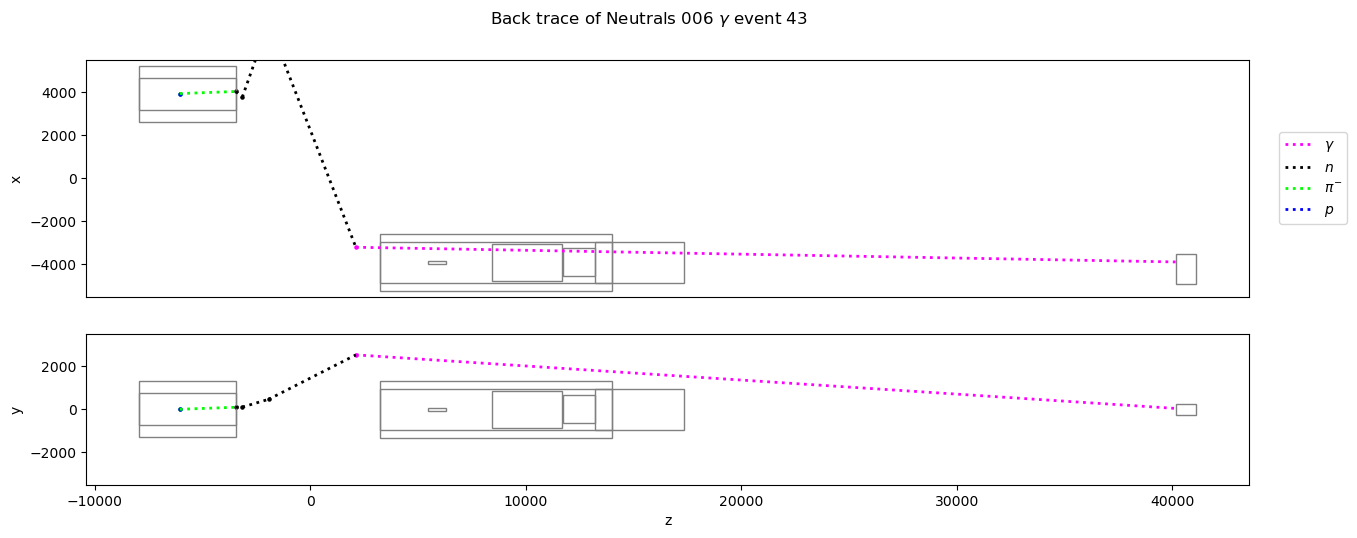

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           7
index                           23
time                 765212.989799
virtualdetectorId              101
creationCode                     2
pdgId                           22
x                     -3937.244203
y                        58.500307
z                         40185.38
px                       71.028807
py                        0.835208
pz                       54.814187
startx                -7757.280809
starty                   42.080445
startz                37214.305504
startpx                -265.166372
startpy                  59.219416
startpz                 432.781398
starttime               765196.625
E                        89.723933
r                        67.286425
weight                    55.07211
Name: 240, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,3028,Neutrals,7,23,765196.625000,765196.625000,13,-11,-7758.169455,42.943051,...,-7757.280809,42.080445,37214.305504,-1.263375e+02,-1672.062397,-2.135787e+02,0.000000e+00,0.000000,-0.000000e+00,1.254926e+03
1,3029,Neutrals,7,23,765194.687500,765196.625000,35,22,-7772.046582,628.389185,...,-7758.169455,42.943051,37213.775656,-2.502777e+02,-4371.146202,-4.781681e+01,1.120719e+02,-4052.269936,-4.516450e+02,4.378566e+03
2,3030,Neutrals,7,23,935.791199,765194.687500,56,2112,3196.936890,-1211.220891,...,-7772.046582,628.389185,37276.286902,-3.182230e+03,1475.775003,1.957974e+04,3.428966e+00,5.642255,-5.946029e+00,2.105369e+02
3,3031,Neutrals,7,23,322.768005,1350.201782,97,2112,3904.060631,-2058.456489,...,2776.250000,-1016.125277,2164.055392,-1.528227e+04,-6483.029366,1.410088e+04,-3.182230e+03,1475.775003,1.957974e+04,2.524297e+02
4,3032,Neutrals,7,23,107.927071,322.768005,97,2112,3265.985525,-1118.315354,...,3904.060631,-2058.456489,-4429.877605,-3.482288e+04,34047.355652,4.178144e+03,1.151863e+04,-30737.258911,3.157606e+04,1.270640e+03
5,3033,Neutrals,7,23,28.057718,107.927071,97,2112,4505.482089,-1132.764893,...,3265.985525,-1118.315354,-5938.477942,-1.248855e+04,-11615.946770,-5.205702e+04,-2.319081e+04,-45338.363647,-1.250723e+04,1.595568e+03
6,3034,Neutrals,7,23,18.172915,28.057718,97,2112,4308.022640,-815.182922,...,4505.482089,-1132.764893,-6140.768100,6.448141e+04,-103708.053589,-1.968936e+05,6.448141e+04,-103708.053589,-1.968936e+05,2.814501e+04
7,3035,Neutrals,7,23,18.075739,18.172915,97,2112,4313.491118,-807.103218,...,4308.022640,-815.182922,-5537.826915,-1.885627e+05,-278602.386475,-1.147149e+05,-1.885627e+05,-278602.386475,-1.147149e+05,6.498318e+04
8,3036,Neutrals,7,23,17.802900,18.075739,97,2112,4299.322725,-768.182576,...,4313.491118,-807.103218,-5534.500086,1.917420e+05,-526716.125488,1.683271e+05,1.917420e+05,-526716.125488,1.683271e+05,1.673727e+05
9,3037,Neutrals,7,23,16.834190,17.802900,97,2112,4269.942044,-632.716665,...,4299.322725,-768.182576,-5546.938279,1.127574e+05,-519892.028809,2.764505e+05,1.127574e+05,-519892.028809,2.764505e+05,1.749793e+05


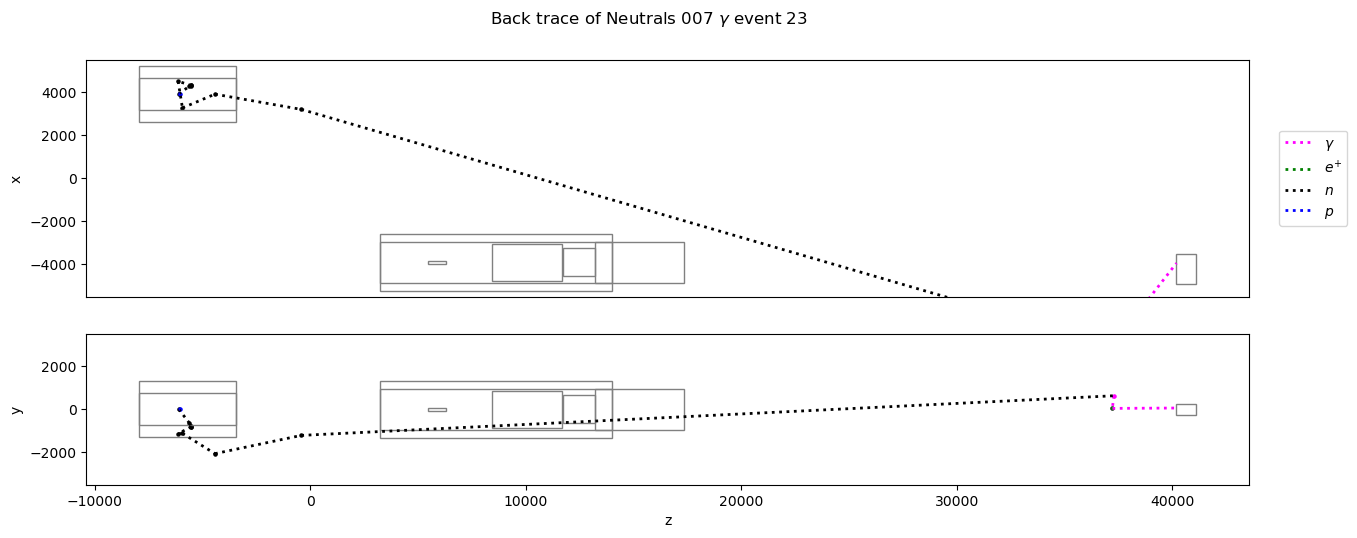

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           8
index                           11
time                 105983.958793
virtualdetectorId              101
creationCode                    35
pdgId                           22
x                     -3841.517712
y                         1.554345
z                         40185.38
px                     -180.994662
py                       56.122318
pz                     2000.945096
startx                 -108.668516
starty                -1155.917093
startz                -1082.280724
startpx                 -180.99466
startpy                  56.122318
startpz                2000.945091
starttime              105845.6875
E                      2009.898022
r                        62.501618
weight                    55.07211
Name: 260, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,3272,Neutrals,8,11,1010.652283,105845.687500,56,2112,523.772972,0.511955,...,-108.668516,-1155.917093,-1082.280724,-2.032166e+03,-1301.312447,-6.396540e+03,-1.226651e+01,-2.156555,6.190469e+00,2.487225e+01
1,3273,Neutrals,8,11,390.543182,1015.550476,97,2112,613.202157,-25.526526,...,520.596998,-1.521804,-324.146428,1.694120e+04,1324.381828,-2.399200e+04,-2.032166e+03,-1301.312447,-6.396540e+03,4.598737e+02
2,3274,Neutrals,8,11,375.659149,390.543182,115,2112,545.807008,192.428049,...,613.202157,-25.526526,0.924158,1.913391e+04,-53386.367798,6.992505e+03,-4.919588e+04,-9275.595665,-1.552321e+04,1.735958e+03
3,3275,Neutrals,8,11,4.665520,55.327522,14,13,3889.797473,-23.667088,...,545.807008,192.428049,-30.359788,1.606995e+04,47199.474335,5.216130e+04,-0.000000e+00,0.000000,-0.000000e+00,2.228899e+04
4,3276,Neutrals,8,11,-5.277191,4.665520,14,-211,3908.786898,13.813159,...,3889.797473,-23.667088,-4889.223041,2.216667e+04,104149.353027,7.150388e+04,5.975036e+04,71256.919861,8.833797e+04,4.998479e+04
5,3277,Neutrals,8,11,-5.414027,-5.277191,101,3122,3909.301171,2.739364,...,3908.786898,13.813159,-6148.680955,-1.454791e+04,313258.483887,-5.971861e+04,-1.454791e+04,313258.483887,-5.971861e+04,4.477280e+04
6,3278,Neutrals,8,11,-5.720356,-5.414027,56,2212,3931.090959,2.649798,...,3909.301171,2.739364,-6146.569882,-2.150417e+06,0.000000,-8.624852e+06,-2.054056e+06,24001.289368,-8.522309e+06,8.000000e+06


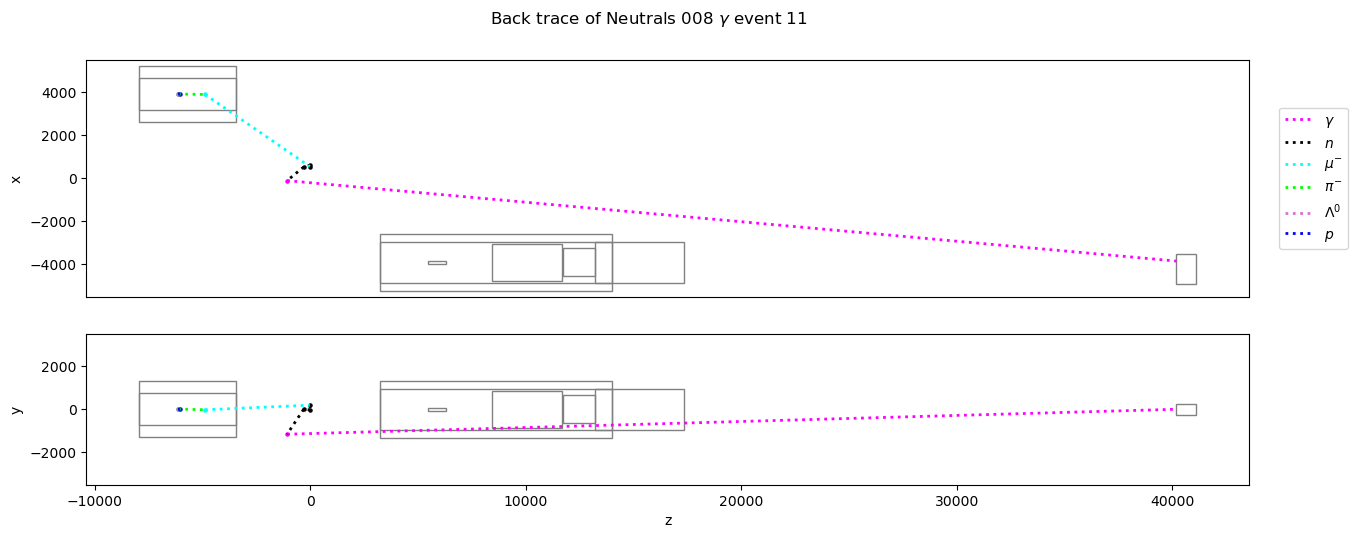

------------------------------------------------------------------------------


tag                        Neutrals
fileno                            8
index                            54
time                 11052082.21509
virtualdetectorId               101
creationCode                     35
pdgId                            22
x                      -3895.596923
y                          87.43774
z                          40185.38
px                       -13.323207
py                         2.259054
pz                       123.561421
startx                   829.485001
starty                   1006.39664
startz                   430.841689
startpx                 -148.437098
startpy                  154.106632
startpz                  510.362864
starttime                11051940.0
E                        124.298173
r                         87.840595
weight                     55.07211
Name: 280, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,3538,Neutrals,8,54,196.645508,1.105194e+07,56,2112,3469.480195,-1757.696959,...,829.485001,1006.396640,430.841689,-1.723856e+04,13536.741257,4.445885e+04,2.978713e+00,-10.192081,-2.778968e+00,1.306611e+03
1,3539,Neutrals,8,54,22.525038,3.906242e+02,97,2112,3987.276969,-722.844617,...,2404.000000,-921.018809,-4195.089891,-3.794934e+03,68418.533325,-6.644341e+03,-1.723856e+04,13536.741257,4.445885e+04,2.518877e+03
2,3540,Neutrals,8,54,18.457291,2.252504e+01,97,2112,4013.114112,-365.493065,...,3987.276969,-722.844617,-6838.463710,-1.047870e+05,-259461.822510,8.606536e+04,-1.777006e+04,-291313.415527,7.768045e+03,4.455407e+04
3,3541,Neutrals,8,54,16.747755,1.845729e+01,97,2112,3939.727162,-238.893854,...,4013.114112,-365.493065,-6856.170365,2.149251e+05,-203716.339111,-3.801637e+05,8.226353e+04,-302821.075439,-3.653619e+05,1.163705e+05
4,3542,Neutrals,8,54,13.660364,1.674776e+01,101,2112,3892.362350,0.208432,...,3939.727162,-238.893854,-6675.930436,5.813232e+04,-293457.733154,-5.640843e+05,5.813232e+04,-293457.733154,-5.640843e+05,1.964236e+05
5,3543,Neutrals,8,54,13.113193,1.366036e+01,56,2212,3931.178964,0.277779,...,3892.362350,0.208432,-6216.328179,-2.150417e+06,0.000000,-8.624852e+06,-2.045115e+06,32055.397034,-8.385547e+06,8.000000e+06


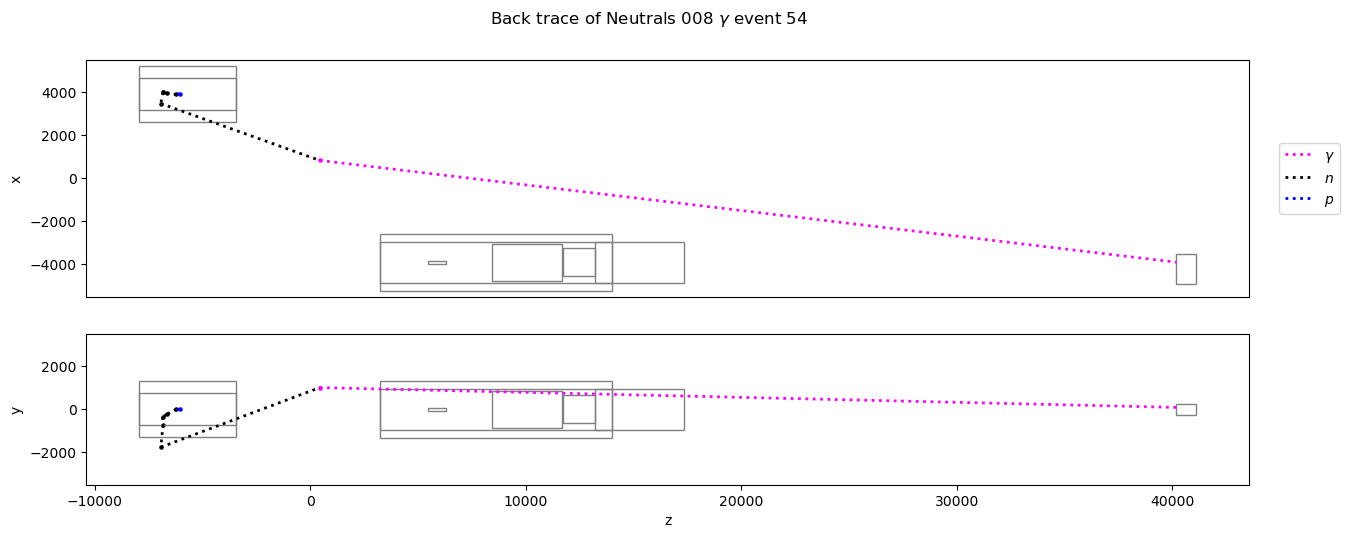

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           9
index                           18
time                 238320.296013
virtualdetectorId              101
creationCode                    35
pdgId                           22
x                     -3938.401205
y                        47.700604
z                         40185.38
px                       18.702743
py                       -2.185186
pz                      139.370873
startx                -7842.053909
starty                  614.426075
startz                   10256.351
startpx               -4322.882175
startpy               -1706.135988
startpz                 638.219357
starttime            238219.015625
E                        140.63715
r                        58.811483
weight                    55.07211
Name: 300, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,3781,Neutrals,9,18,766.282593,238219.015625,56,2112,572.976211,-54.191724,...,-7842.053909,614.426075,10256.351000,-2.696294e+03,1096.032619,6.397062e+03,4.927071e+00,-4.403490,1.333836e+00,2.628503e+01
1,3782,Neutrals,9,18,273.863251,771.400330,97,2112,716.087630,-61.202426,...,568.573452,-52.402020,319.886309,-4.886746e+03,-7569.544315,-2.243539e+04,-2.696294e+03,1096.032619,6.397062e+03,3.110100e+02
2,3783,Neutrals,9,18,262.130890,273.863251,97,2112,796.221614,-17.944652,...,716.087630,-61.202426,47.241704,-9.475619e+03,-45645.496368,1.021419e+04,-4.032890e+04,2890.809298,1.595383e+04,1.211284e+03
3,3784,Neutrals,9,18,252.269562,262.130890,115,2112,727.392931,190.271874,...,796.221614,-17.944652,-6.256974,2.152152e+04,-66491.996765,1.916105e+04,3.277604e+04,-63214.130402,-1.275286e+04,2.790503e+03
4,3785,Neutrals,9,18,27.272324,65.326935,14,13,3807.921749,62.803918,...,727.392931,190.271874,-62.650168,-2.332281e+04,-13945.292473,5.119119e+04,-0.000000e+00,-0.000000,-0.000000e+00,1.485161e+04
5,3786,Neutrals,9,18,9.501429,27.272324,101,-211,3905.056500,0.803033,...,3807.921749,62.803918,-3074.046109,3.589264e+04,41862.018585,1.160467e+05,-2.035386e+04,-34841.518402,1.077584e+05,5.013325e+04
6,3787,Neutrals,9,18,9.500565,9.501429,101,2212,3905.066026,0.856989,...,3905.056500,0.803033,-6165.195024,-1.616844e+05,-912006.713867,-4.169843e+06,-1.595367e+05,-911167.175293,-4.169596e+06,3.435039e+06
7,3788,Neutrals,9,18,9.130969,9.500565,56,2212,3931.494479,0.778758,...,3905.066026,0.856989,-6164.948032,-2.150417e+06,0.000000,-8.624852e+06,-2.138802e+06,37409.549713,-8.437312e+06,8.000000e+06


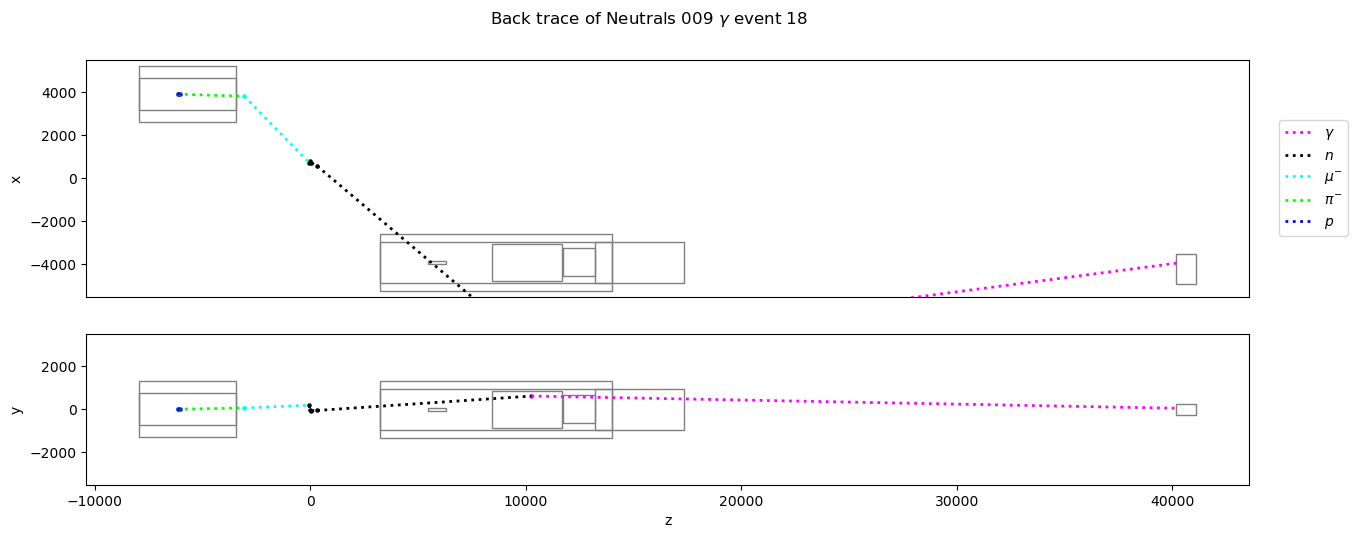

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          9
index                          59
time                 874827.72641
virtualdetectorId             101
creationCode                   35
pdgId                          22
x                    -3877.286368
y                       54.082596
z                        40185.38
px                     -56.296365
py                    -413.641542
pz                    1588.704177
startx                  25.012856
starty                  27.398147
startz                1042.500729
startpx               -259.171277
startpy                216.588348
startpz               2068.370819
starttime             874694.6875
E                     1642.634947
r                       60.320356
weight                   55.07211
Name: 320, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,4044,Neutrals,9,59,330970.687500,874694.687500,56,2112,4934.563325,2869.600000,...,25.012856,27.398147,1042.500729,-4.747955e+01,-24.658816,7.464407e+01,1.355774e+00,-10.152324,2.867350e+00,4.488300e-03
1,4045,Neutrals,9,59,1.778073,613251.687500,97,2112,992.806515,185.873212,...,658.127035,648.604869,1370.950000,3.278447e+03,-24733.819962,9.324673e+03,-4.747955e+01,-24.658816,7.464407e+01,3.774709e+02
2,4046,Neutrals,9,59,0.566803,1.778073,97,2112,1108.861528,53.467399,...,992.806515,185.873212,-18153.834530,-3.559339e+05,385316.467285,8.664863e+04,-2.588378e+05,457562.957764,7.784943e+04,1.399942e+05
3,4047,Neutrals,9,59,-0.213844,0.566803,101,2112,1275.252481,25.997907,...,1108.861528,53.467399,-18182.423000,-9.705996e+05,160236.343384,-1.147498e+05,-9.705996e+05,160236.343384,-1.147498e+05,4.256049e+05
4,4048,Neutrals,9,59,-41.443718,-0.213844,101,2212,3885.381153,-1.482738,...,1275.252481,25.997907,-18162.751312,-1.288972e+06,-116699.707031,-5.778024e+06,-1.147927e+06,24768.138885,-5.579980e+06,5.056808e+06
5,4049,Neutrals,9,59,-42.074871,-41.443718,56,2212,3930.328503,0.773782,...,3885.381153,-1.482738,-6240.358046,-2.150417e+06,0.000000,-8.624852e+06,-2.072829e+06,-128332.977295,-8.278496e+06,8.000000e+06


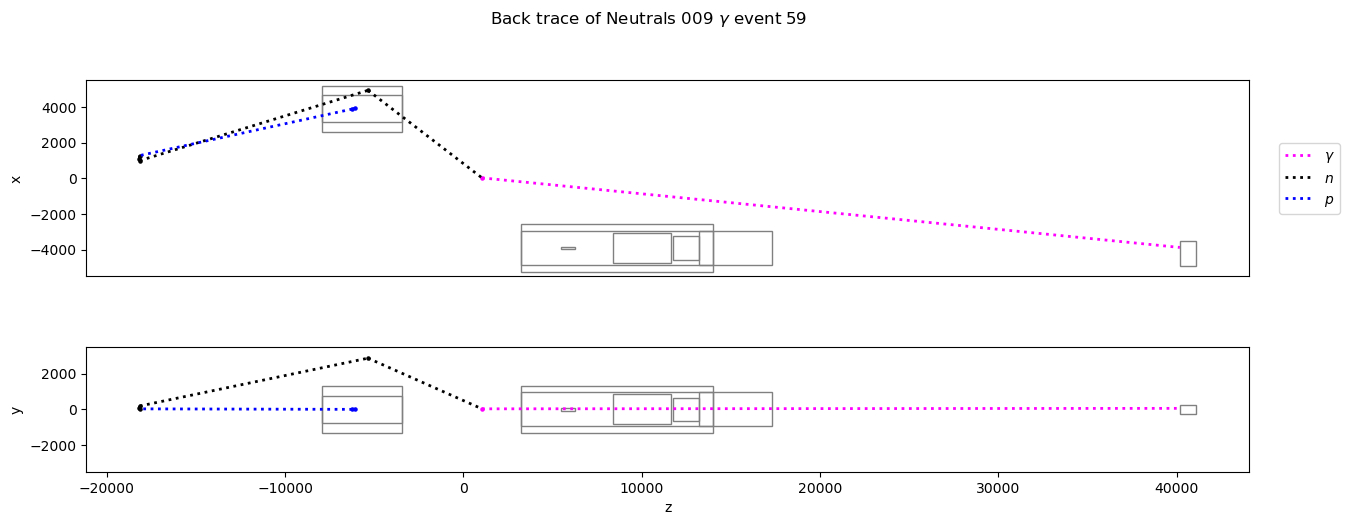

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          0
index                           0
time                   5218.75841
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3839.371156
y                       -7.111976
z                         40185.4
px                   13895.520031
py                    3502.492323
pz                   -8111.347723
startx               -3920.156563
starty                 -59.807963
startz               40244.867553
startpx              -9515.187263
startpy              14351.628304
startpz              -1532.535434
starttime             5177.271484
E                      144.282711
r                       65.018979
weight                   55.07211
Name: 0, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,0,Neutrals,0,0,5163.173340,5177.271484,97,2112,-3944.655270,-41.217060,...,-3920.156563,-59.807963,40244.867553,1.937859e+04,-12500.455856,-7.924359e+02,-4.254562e+03,-7562.680244,2.093174e+04,2.832899e+02
1,1,Neutrals,0,0,179.821777,5163.173340,56,2112,1055.706151,-130.775866,...,-3944.655270,-41.217060,40209.388797,-2.293581e+04,-30080.778122,2.508760e+04,-1.124263e+04,5685.481071,-2.387218e+04,1.095768e+03
2,2,Neutrals,0,0,139.348770,180.719437,115,2112,1351.207248,256.764373,...,1049.144433,-139.381690,291.800014,1.831582e+04,25855.476379,-3.701518e+04,-2.293581e+04,-30080.778122,2.508760e+04,1.262554e+03
3,3,Neutrals,0,0,43.271366,72.124245,14,13,3922.176867,-33.913975,...,1351.207248,256.764373,-38.459296,2.940652e+02,55942.661285,1.166918e+05,-0.000000e+00,-0.000000,-0.000000e+00,6.140550e+04
4,4,Neutrals,0,0,37.227337,43.271366,101,-211,3890.061069,-0.608959,...,3922.176867,-33.913975,-4978.615432,-7.056548e+04,19613.492966,1.562046e+05,3.096302e+03,32390.556335,1.377879e+05,8.233945e+04
5,5,Neutrals,0,0,36.638817,37.227337,56,2212,3933.283752,-0.421516,...,3890.061069,-0.608959,-6228.458598,-2.150417e+06,0.000000,-8.624852e+06,-2.148609e+06,24816.308975,-8.350406e+06,8.000000e+06


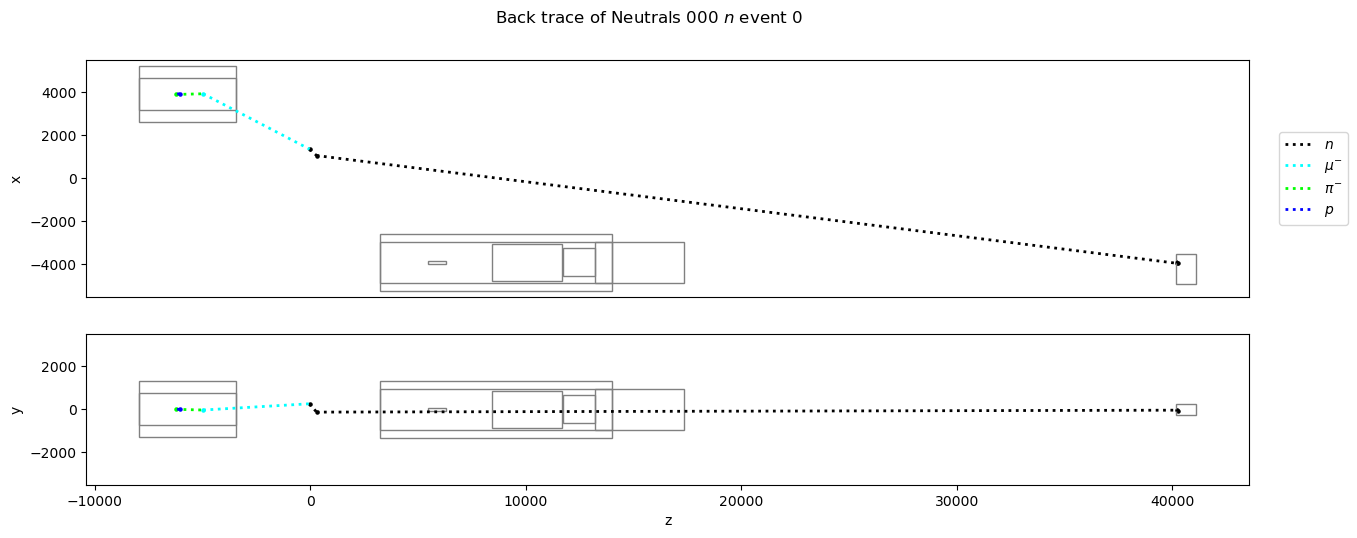

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           0
index                           43
time                 463374.488356
virtualdetectorId              101
creationCode                    97
pdgId                         2112
x                     -3894.000535
y                       -18.577016
z                          40185.4
px                       -39.76636
py                     -174.118525
pz                     -192.191925
startx                  487.749579
starty                -1954.074944
startz                 1054.389996
startpx               27331.825256
startpy              -23156.831741
startpz                6214.764595
starttime               641.228027
E                         0.036632
r                        21.097271
weight                    55.07211
Name: 20, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,270,Neutrals,0,43,348.316986,641.228027,56,2112,2810.626622,-1215.157468,...,487.749579,-1954.074944,1054.389996,-3.166353e+04,-10159.318924,3.234284e+04,-3.806471e+04,6195.986748,-1.314389e+04,1.144434e+03
1,271,Neutrals,0,43,134.188477,520.813843,97,2112,4607.514584,-755.373260,...,1070.000000,-1773.641598,967.297927,7.279374e+03,14760.029793,4.650526e+04,-3.166353e+04,-10159.318924,3.234284e+04,1.294169e+03
2,272,Neutrals,0,43,133.205566,134.188477,97,2112,4615.873658,-756.483701,...,4607.514584,-755.373260,-3148.667387,-4.824770e+04,-12451.606750,2.389134e+04,-2.363930e+04,38069.740295,2.640834e+04,1.623646e+03
3,273,Neutrals,0,43,126.037964,133.205566,97,2112,4457.562737,-716.454010,...,4615.873658,-756.483701,-3154.826617,6.942615e+04,-17554.740906,9.464729e+03,6.942615e+04,-17554.740906,9.464729e+03,2.772587e+03
4,274,Neutrals,0,43,112.772980,126.037964,97,2112,4170.687076,-657.472315,...,4457.562737,-716.454010,-3176.408831,4.522686e+04,-35825.706482,1.098021e+05,7.790852e+04,-5077.756405,9.616878e+04,8.152168e+03
5,275,Neutrals,0,43,108.852242,112.772980,97,2112,4052.756195,-504.000880,...,4170.687076,-657.472315,-3596.656269,9.639786e+04,-125449.050903,1.237060e+05,9.639786e+04,-125449.050903,1.237060e+05,2.122403e+04
6,276,Neutrals,0,43,101.599770,108.852242,115,2112,4043.983903,-91.163842,...,4052.756195,-504.000880,-3747.995344,-1.784413e+05,-121322.174072,1.449399e+05,1.222683e+05,-215180.999756,7.309284e+04,3.529412e+04
7,277,Neutrals,0,43,57.823917,80.899521,14,13,3925.826374,-0.038873,...,4043.983903,-91.163842,-3972.054652,-9.997362e+03,-82552.131653,1.555173e+04,0.000000e+00,0.000000,0.000000e+00,2.969431e+04
8,278,Neutrals,0,43,46.357944,57.823917,101,-211,3925.034553,-0.705298,...,3925.826374,-0.038873,-5647.359071,-7.465629e+04,-91303.382874,1.091201e+04,-4.243109e+04,-84886.779785,3.196618e+04,4.348385e+04
9,279,Neutrals,0,43,46.258755,46.357944,56,2212,3932.181636,-0.848676,...,3925.034553,-0.705298,-6086.852347,-2.150417e+06,0.000000,-8.624852e+06,-2.139035e+06,69143.783569,-8.581592e+06,8.000000e+06


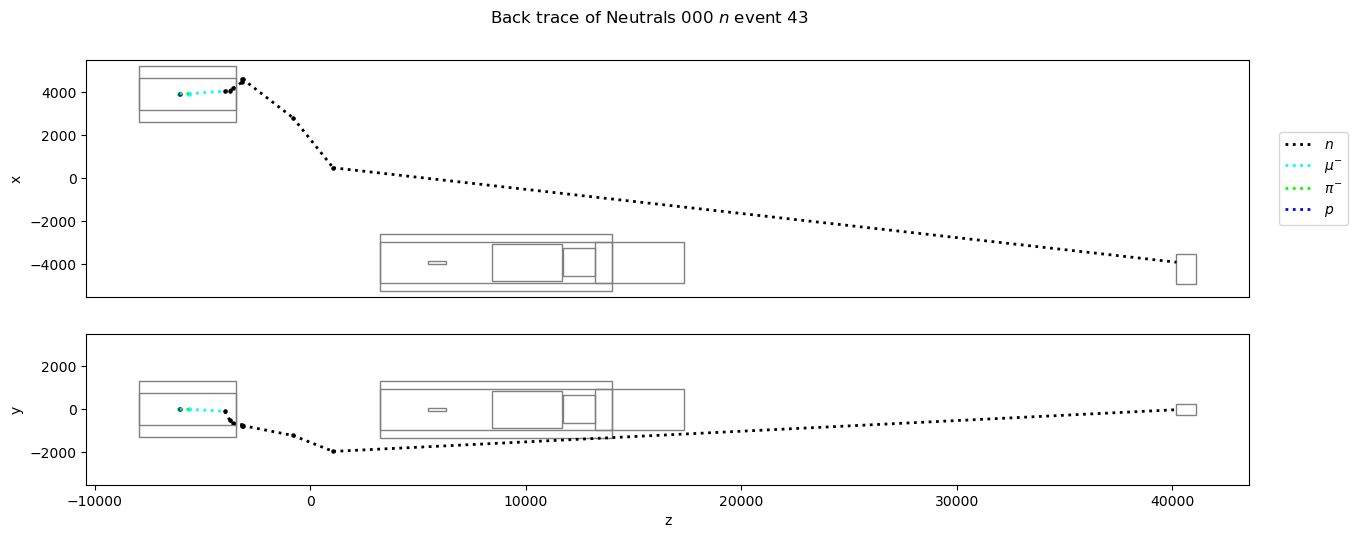

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           1
index                           15
time                 446791.661297
virtualdetectorId              101
creationCode                    56
pdgId                         2112
x                     -3849.833905
y                        83.209197
z                          40185.4
px                      125.245593
py                       63.361524
pz                     -254.281132
startx                 2910.833673
starty                -1228.838192
startz                     -3993.1
startpx               -2512.861967
startpy                4302.692413
startpz               23992.256165
starttime               254.874481
E                         0.044893
r                        99.286133
weight                    55.07211
Name: 40, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,500,Neutrals,1,15,-36.020603,574.003662,97,2112,3829.771985,-902.200954,...,2655.045032,-790.859587,-1550.886091,-2.475145e+04,-799.983323,3.233660e+03,-2.512862e+03,4302.692413,2.399226e+04,3.318665e+02
1,501,Neutrals,1,15,-50.795284,-36.020603,97,2112,3825.728361,-729.109054,...,3829.771985,-902.200954,-5973.071345,1.859798e+04,-44568.149567,4.719008e+02,-3.001446e+03,-35066.677094,3.265010e+04,1.240408e+03
2,502,Neutrals,1,15,-52.037205,-50.795284,97,2112,3907.971246,-700.074938,...,3825.728361,-729.109054,-6099.714736,-2.146874e+05,-75790.870667,9.986694e+04,-2.146874e+05,-75790.870667,9.986694e+04,3.233557e+04
3,503,Neutrals,1,15,-55.352959,-52.037205,97,2112,3778.462941,-259.525918,...,3907.971246,-700.074938,-6137.971957,2.012450e+05,-452030.059814,-1.425671e+04,1.014697e+05,-484019.317627,1.219052e+04,1.224220e+05
4,504,Neutrals,1,15,-55.412365,-55.352959,97,2112,3775.242006,-251.643642,...,3778.462941,-259.525918,-6109.301160,1.975478e+05,-483439.178467,1.939167e+05,1.975478e+05,-483439.178467,1.939167e+05,1.527374e+05
5,505,Neutrals,1,15,-55.574738,-55.412365,97,2112,3768.820442,-225.515779,...,3775.242006,-251.643642,-6112.462891,1.491045e+05,-606671.875000,-6.646787e+04,1.491045e+05,-606671.875000,-6.646787e+04,1.906930e+05
6,506,Neutrals,1,15,-57.090595,-55.574738,101,2112,3907.334100,2.175372,...,3768.820442,-225.515779,-6109.600284,-3.559861e+05,-585176.025391,1.101676e+05,-3.559861e+05,-585176.025391,1.101676e+05,2.283717e+05
7,507,Neutrals,1,15,-57.417717,-57.090595,56,2212,3931.036431,1.837264,...,3907.334100,2.175372,-6152.466345,-2.150417e+06,0.000000,-8.624852e+06,-2.125111e+06,51276.744843,-8.456731e+06,8.000000e+06


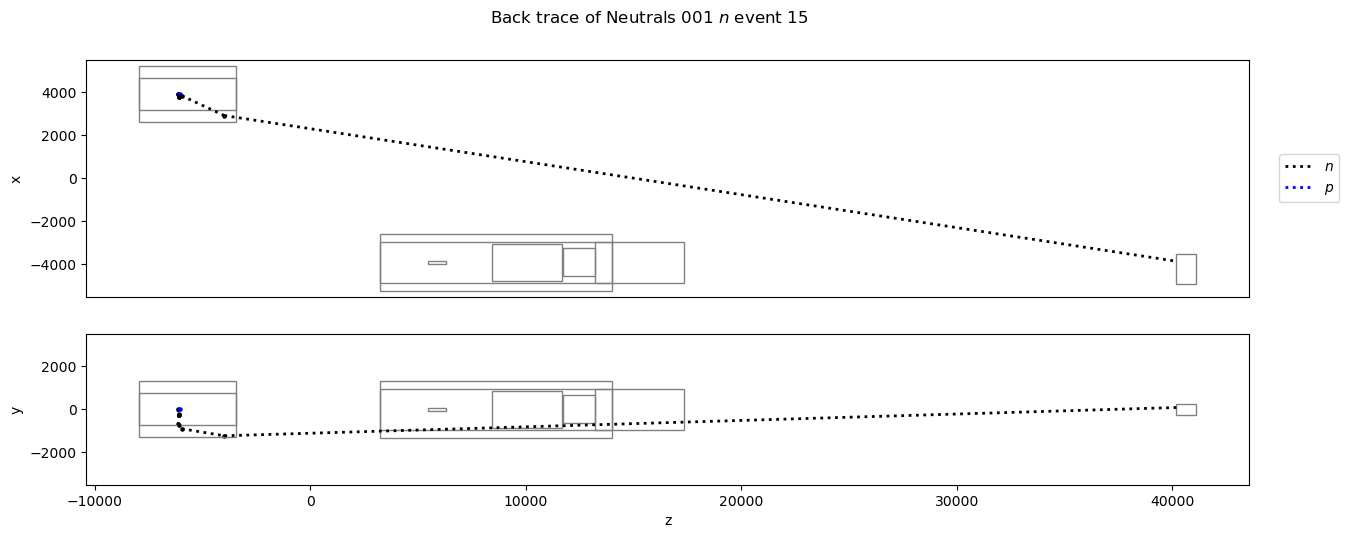

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          1
index                          66
time                 37281.679735
virtualdetectorId             101
creationCode                   56
pdgId                        2112
x                    -3953.597846
y                      -73.294655
z                        40185.38
px                    -154.916499
py                    -225.423371
pz                     3313.04939
startx                  850.11925
starty                 310.386546
startz                  48.481072
startpx               1572.489619
startpy              18086.610794
startpz                616.045773
starttime               110.70388
E                        5.880951
r                       88.498886
weight                   55.07211
Name: 60, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,801,Neutrals,1,66,68.941071,112.448341,97,2112,838.627336,235.101931,...,850.994358,320.451944,48.823908,1.792239e+04,-1247.597694,9.223067e+03,1.572490e+03,18086.610794,6.160458e+02,2.170081e+02
1,802,Neutrals,1,66,68.094337,68.941071,78,2112,838.923210,215.305193,...,838.627336,235.101931,8.021649,-1.101080e+03,73672.637939,-6.464870e+04,-1.101080e+03,73672.637939,-6.464870e+04,5.099337e+03
2,803,Neutrals,1,66,26.874907,68.094337,101,-211,3920.434990,1.737514,...,838.923210,215.305193,25.393546,-2.572322e+04,27123.363495,1.202976e+05,-0.000000e+00,-0.000000,0.000000e+00,4.844234e+04
3,804,Neutrals,1,66,26.743370,26.874907,56,2212,3929.736234,1.585071,...,3920.434990,1.737514,-6095.644194,-2.150417e+06,0.000000,-8.624852e+06,-2.047934e+06,58768.138885,-8.593756e+06,8.000000e+06


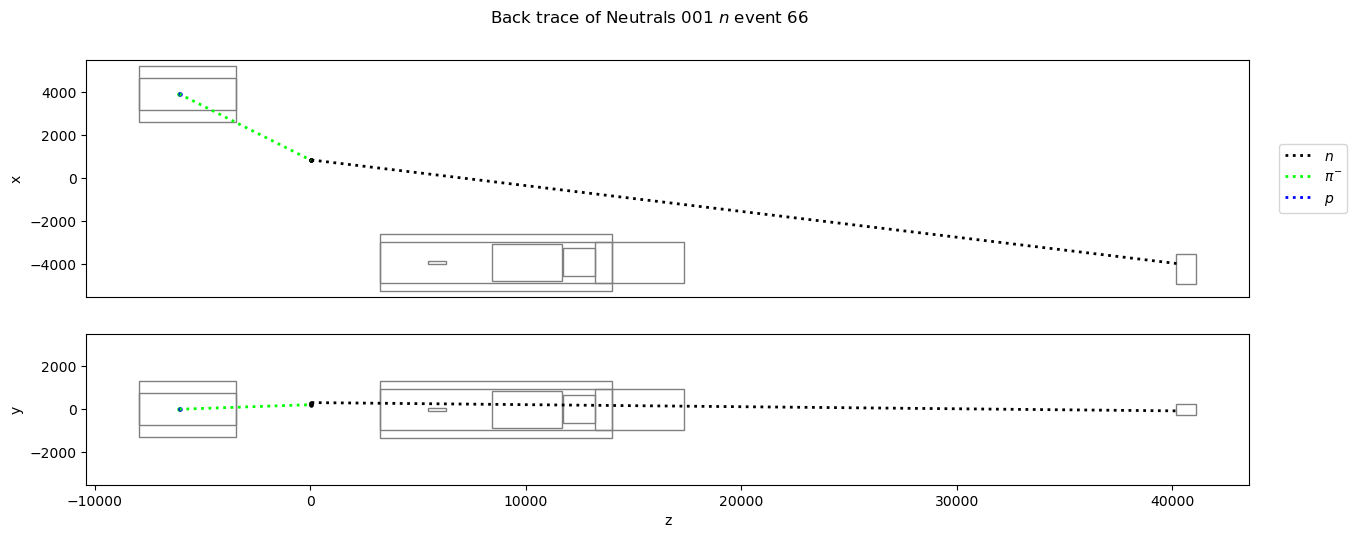

------------------------------------------------------------------------------


tag                        Neutrals
fileno                            2
index                            30
time                 7096642.766245
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -4001.154312
y                          4.385212
z                          40185.38
px                         1.815348
py                         3.893911
pz                         1.753215
startx                   -265.73012
starty                  -141.510386
startz                  -629.736664
startpx               -18446.617126
startpy               -18450.485229
startpz                 5262.536526
starttime                149.945541
E                          0.000011
r                         97.253229
weight                     55.07211
Name: 80, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,1013,Neutrals,2,30,142.946808,149.945541,56,2112,-137.685726,-25.579272,...,-265.730120,-141.510386,-629.736664,-5.820507e+04,-52698.749542,-1.439302e+05,-5.820507e+04,-52698.749542,-1.439302e+05,1.419770e+04
1,1014,Neutrals,2,30,137.350464,143.161880,115,2112,0.057857,64.039310,...,-141.620711,-29.141999,-322.837368,-1.017172e+05,-48906.665802,-1.190953e+05,-5.820507e+04,-52698.749542,-1.439302e+05,1.421921e+04
2,1015,Neutrals,2,30,40.998474,122.097038,14,13,2401.118016,57.241785,...,0.057857,64.039310,-80.106374,-1.076277e+04,-3902.990818,3.046126e+03,-0.000000e+00,-0.000000,0.000000e+00,6.620922e+02
3,1016,Neutrals,2,30,-30.801645,40.998474,101,-211,3885.111052,1.728028,...,2401.118016,57.241785,-475.328942,-4.656355e+04,65839.485168,7.223263e+04,-4.437551e+04,-28822.156906,1.598360e+04,3.706614e+04
4,1017,Neutrals,2,30,-31.453806,-30.801645,56,2212,3931.940592,0.114937,...,3885.111052,1.728028,-6246.757802,-2.150417e+06,0.000000,-8.624852e+06,-2.129481e+06,113043.777466,-8.298570e+06,8.000000e+06


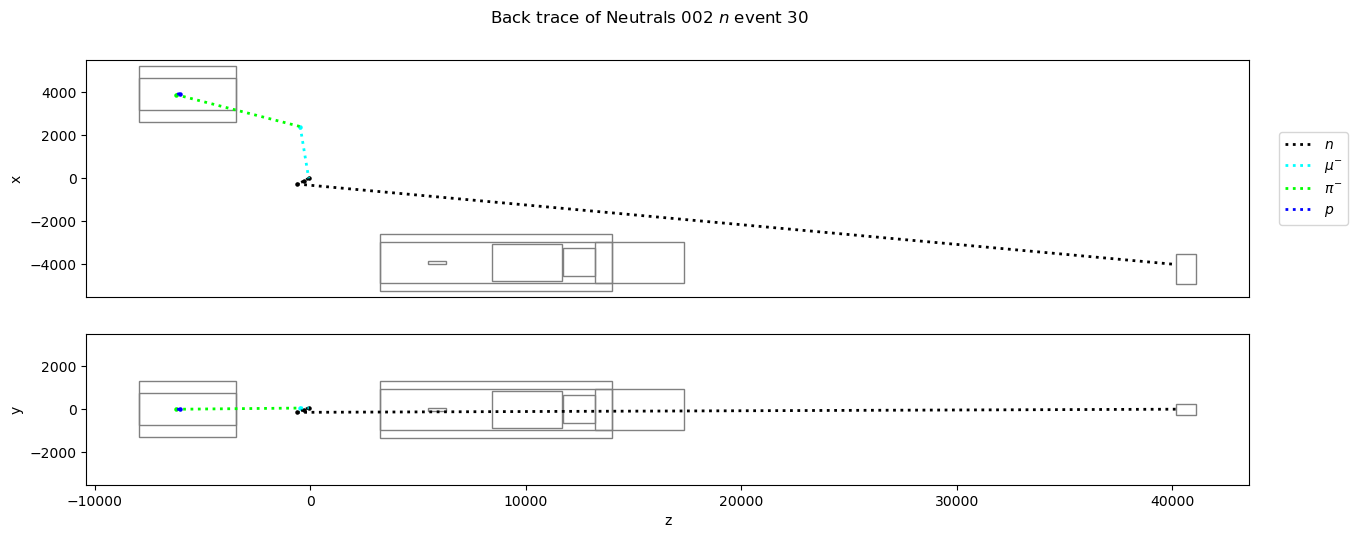

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          3
index                           3
time                 10888.283431
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3960.307531
y                       -68.13738
z                        40185.38
px                   -1284.135155
py                    -470.308606
pz                   12766.323469
startx                 998.982848
starty                -285.862886
startz                -330.028515
startpx              14081.476212
startpy             -32291.213989
startpz                 4409.7929
starttime               77.030762
E                       87.722217
r                       88.392537
weight                   55.07211
Name: 100, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,1293,Neutrals,3,3,68.875694,77.030762,56,2112,955.946854,-200.614945,...,998.982848,-285.862886,-330.028515,1.195167e+04,-46286.777496,-3.470837e+04,8.046951e+03,-45136.005402,-3.359550e+04,1.855399e+03
1,1294,Neutrals,3,3,39.823883,69.433289,97,2112,843.025241,207.628572,...,958.069040,-208.833814,-247.914623,3.899853e+04,43809.505463,2.246954e+04,1.195167e+04,-46286.777496,-3.470837e+04,2.097055e+03
2,1295,Neutrals,3,3,37.927315,39.823883,78,2112,844.333604,227.865447,...,843.025241,207.628572,70.166892,-2.171729e+03,-33590.820312,8.237531e+04,-2.171729e+03,-33590.820312,8.237531e+04,4.204642e+03
3,1296,Neutrals,3,3,-10.798385,37.927315,14,-211,3908.265598,15.797905,...,844.333604,227.865447,20.539680,-3.884509e+04,28587.898254,8.952448e+04,-0.000000e+00,0.000000,-0.000000e+00,3.311646e+04
4,1297,Neutrals,3,3,-10.957279,-10.798385,101,3112,3908.262616,0.514698,...,3908.265598,15.797905,-6160.963064,1.502858e+04,474175.781250,-6.070510e+05,-1.045146e+04,453538.513184,-6.046044e+05,2.264411e+05
5,1298,Neutrals,3,3,-11.245070,-10.957279,56,2212,3928.937446,0.024106,...,3908.262616,0.514698,-6140.614653,-2.150417e+06,0.000000,-8.624852e+06,-2.134188e+06,74246.368408,-8.508537e+06,8.000000e+06


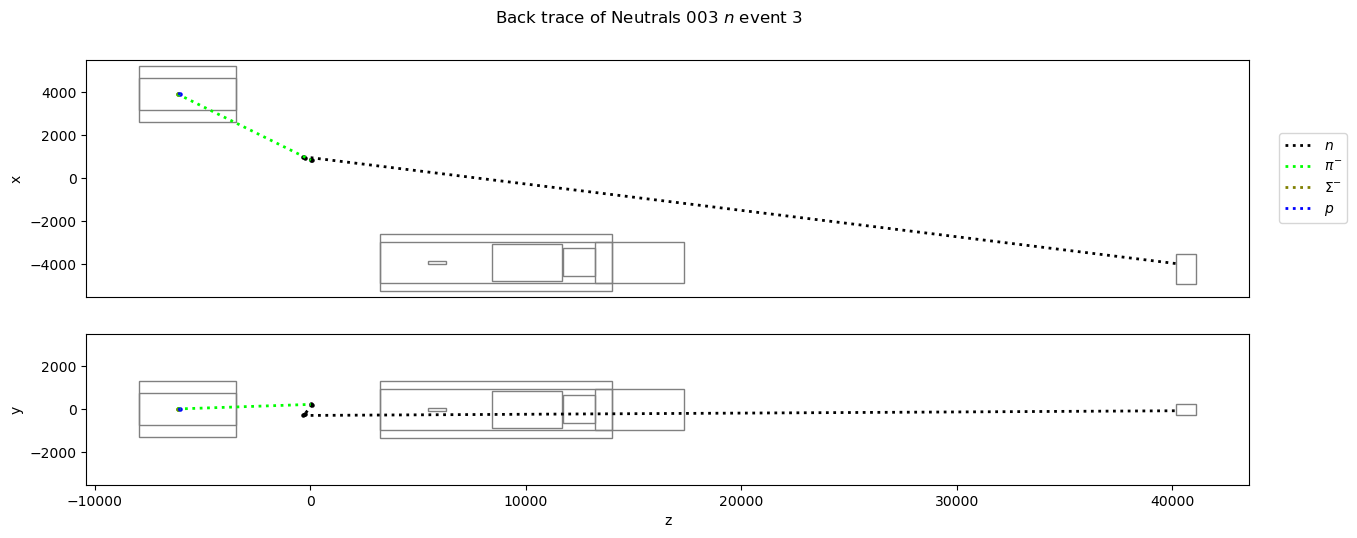

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          3
index                          27
time                 60015.001956
virtualdetectorId             101
creationCode                   56
pdgId                        2112
x                    -3820.912136
y                       -2.698156
z                        40185.38
px                    -261.236674
py                     320.361931
pz                    2095.402573
startx                1036.615594
starty                  261.39023
startz                -174.945788
startpx               9853.425026
startpy              28050.754547
startpz              -3942.314625
starttime              264.242828
E                        2.427496
r                       83.131662
weight                   55.07211
Name: 120, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,1418,Neutrals,3,27,186.338089,265.472809,115,2112,756.911948,191.917717,...,1040.480601,272.393143,-176.492161,7.476111e+03,-30659.320831,-9.395113e+02,9.853425e+03,28050.754547,-3.942315e+03,5.302918e+02
1,1419,Neutrals,3,27,68.542641,118.647118,14,13,3899.189890,37.146402,...,756.911948,191.917717,109.823228,-1.252284e+04,-42377.170563,4.023865e+04,-0.000000e+00,0.000000,-0.000000e+00,1.573144e+04
2,1420,Neutrals,3,27,7.294425,68.542641,101,-211,3911.494574,1.249021,...,3899.189890,37.146402,-3024.627945,6.480802e+04,-50600.517273,3.156560e+04,3.552711e+03,-26730.451584,3.126899e+04,2.546531e+04
3,1421,Neutrals,3,27,7.007067,7.294425,56,2212,3931.701106,1.201312,...,3911.494574,1.249021,-6141.286461,-2.150417e+06,0.000000,-8.624852e+06,-2.059948e+06,-13369.021416,-8.515442e+06,8.000000e+06


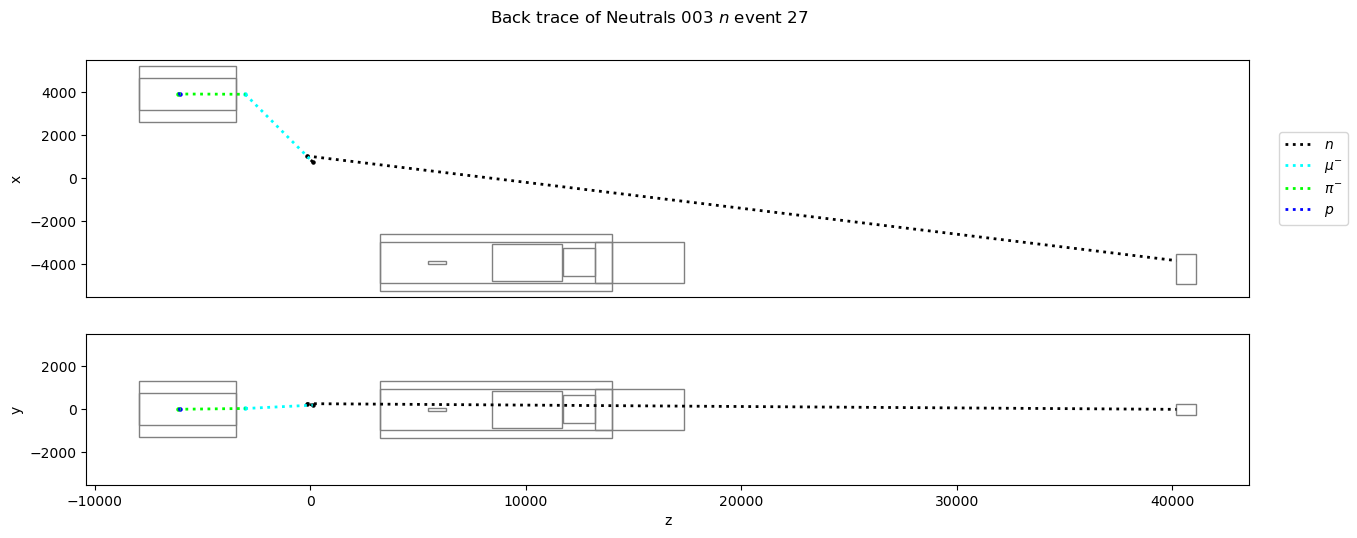

------------------------------------------------------------------------------


tag                         Neutrals
fileno                             3
index                             64
time                 12449628.579098
virtualdetectorId                101
creationCode                      56
pdgId                           2112
x                       -3877.362924
y                         -21.108994
z                           40185.38
px                          1.066371
py                          0.590458
pz                         13.800205
startx                  -3392.784302
starty                   -127.175746
startz                    884.955013
startpx                -25522.792816
startpy                -13771.312714
startpz                  2598.240614
starttime                 467.645477
E                           0.000102
r                          33.987107
weight                      55.07211
Name: 140, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,1621,Neutrals,3,64,176.557892,473.981018,97,2112,-1313.372260,208.875368,...,-3444.354308,-155.001333,890.204881,-1.102178e+04,16793.270111,2.326488e+04,-2.552279e+04,-13771.312714,2.598241e+03,5.026237e+02
1,1622,Neutrals,3,64,91.802513,176.557892,97,2112,296.624309,-22.870203,...,-1313.372260,208.875368,-126.435604,-1.047310e+04,-63418.670654,-1.058349e+04,2.872338e+04,-30647.947311,-4.544661e+04,2.255583e+03
2,1623,Neutrals,3,64,60.403870,91.802513,78,2112,1042.172968,252.114526,...,296.624309,-22.870203,19.285204,-6.430837e+04,17543.733597,4.462844e+04,-7.473739e+04,-27775.608063,2.596621e+03,3.418263e+03
3,1624,Neutrals,3,64,20.225363,60.403870,101,-211,3902.715528,0.507174,...,1042.172968,252.114526,-8.758614,9.302665e+03,45101.779938,1.654123e+05,-0.000000e+00,0.000000,0.000000e+00,8.170291e+04
4,1625,Neutrals,3,64,19.819719,20.225363,56,2212,3931.303953,-0.137100,...,3902.715528,0.507174,-6175.434436,-2.150417e+06,0.000000,-8.624852e+06,-1.979432e+06,98398.994446,-8.484946e+06,8.000000e+06


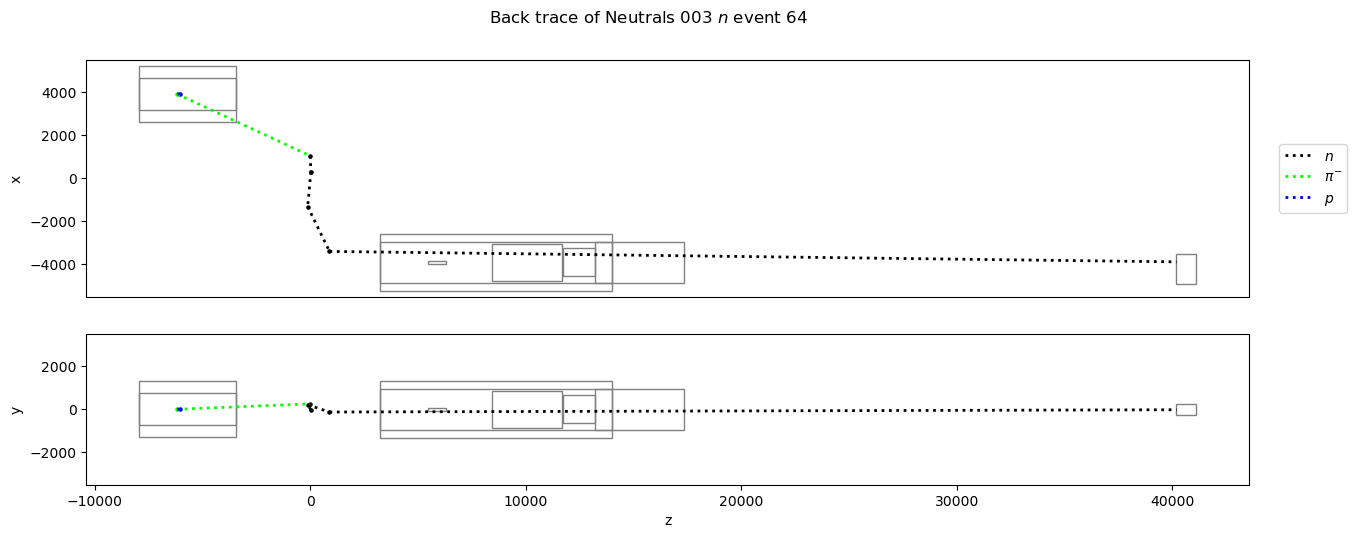

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          4
index                          26
time                  6571.930447
virtualdetectorId             101
creationCode                   56
pdgId                        2112
x                     -3890.43506
y                       58.461903
z                        40185.38
px                   -2071.336497
py                    -431.560688
pz                   22075.383141
startx                 964.920061
starty                 264.349128
startz                 169.734383
startpx             -31228.540421
startpy               7434.426785
startpz              34461.414337
starttime              313.916077
E                      261.679903
r                       60.015012
weight                   55.07211
Name: 160, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,1830,Neutrals,4,26,304.557098,315.158539,115,2112,1058.058496,242.176115,...,952.555515,267.292696,183.378944,-3.122854e+04,7434.426785,3.446141e+04,-3.122854e+04,7434.426785,3.446141e+04,1.179636e+03
1,1831,Neutrals,4,26,71.273201,147.205124,14,13,3908.975494,82.675126,...,1058.058496,242.176115,66.953978,-4.179225e+04,-36641.403198,2.666730e+04,0.000000e+00,0.000000,-0.000000e+00,1.666914e+04
2,1832,Neutrals,4,26,54.253750,71.273201,99,-211,3884.666560,4.468110,...,3908.975494,82.675126,-6252.480566,1.874493e+04,-90954.673767,-7.716543e+03,-6.612262e+04,-27069.751740,4.124226e+03,2.824968e+04
3,1833,Neutrals,4,26,54.141304,54.253750,101,211,3887.847037,0.329943,...,3884.666560,4.468110,-6270.745621,-1.107483e+05,94581.245422,-9.073455e+05,-1.067435e+05,121437.721252,-8.530712e+05,7.899278e+05
4,1834,Neutrals,4,26,53.520283,54.141304,56,2212,3930.373996,0.032998,...,3887.847037,0.329943,-6237.864998,-2.150417e+06,0.000000,-8.624852e+06,-1.986742e+06,118857.009888,-8.359373e+06,8.000000e+06


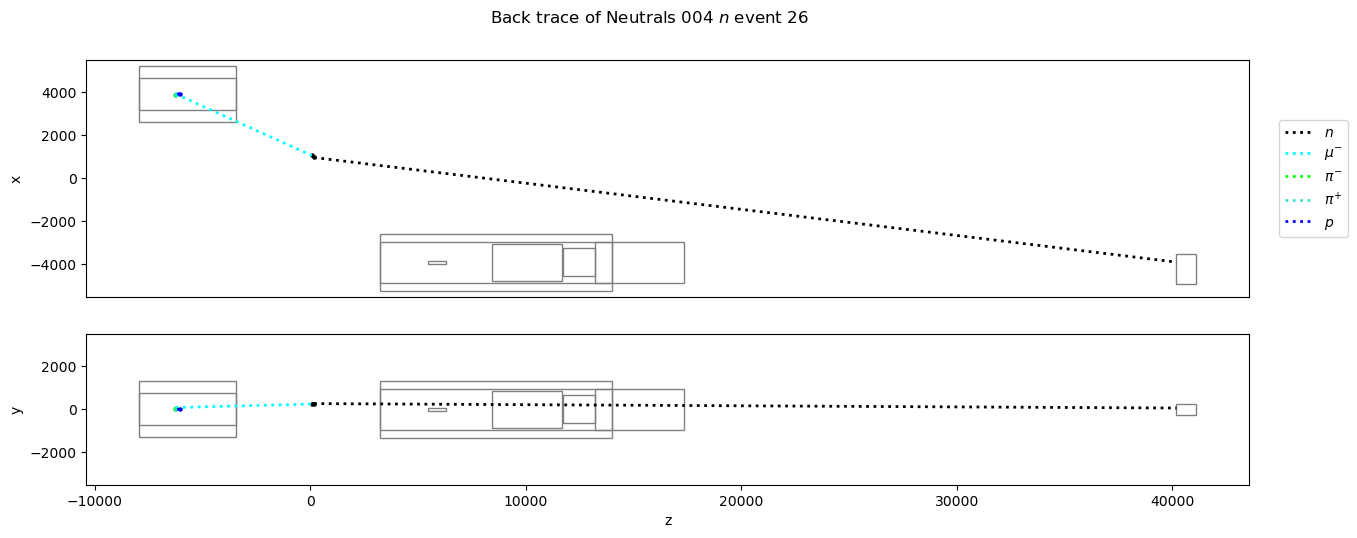

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          5
index                           9
time                 49133.359721
virtualdetectorId             101
creationCode                   97
pdgId                        2112
x                    -3826.140036
y                       22.811701
z                        40185.38
px                    -158.453018
py                    -129.160322
pz                    2778.800717
startx                 -22.791499
starty                 928.969725
startz                 201.992932
startpx               8438.924789
startpy              -2087.846041
startpz              -4861.580849
starttime               258.83078
E                        4.131435
r                       81.132901
weight                   55.07211
Name: 180, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,2153,Neutrals,5,9,214.059311,258.830780,97,2112,26.484464,597.344785,...,-22.791499,928.969725,201.992932,-2.897141e+04,25115.339279,-2.436276e+04,-1.883633e+04,17561.149597,3.277812e+04,1.097562e+03
1,2154,Neutrals,5,9,209.582855,214.059311,56,2112,139.133743,307.767648,...,26.484464,597.344785,131.451996,-8.118229e+04,208687.850952,4.932919e+04,-8.118229e+04,208687.850952,4.932919e+04,2.757352e+04
2,2155,Neutrals,5,9,207.773392,209.733353,115,2112,184.668056,190.716779,...,135.346266,317.503765,65.303764,-8.118229e+04,208687.850952,4.932919e+04,-8.118229e+04,208687.850952,4.932919e+04,2.757352e+04
3,2156,Neutrals,5,9,-27.889996,2.295285,14,13,3762.775631,43.208786,...,184.668056,190.716779,35.334123,-9.134847e+03,11984.039307,5.969305e+04,-0.000000e+00,0.000000,0.000000e+00,1.662824e+04
4,2157,Neutrals,5,9,-52.526569,-27.889996,101,-211,3930.333976,0.391798,...,3762.775631,43.208786,-1924.215874,1.463116e+04,-31875.658035,1.212003e+05,-4.568383e+04,-4362.246037,8.696177e+04,4.857730e+04
5,2158,Neutrals,5,9,-52.540668,-52.526569,56,2212,3931.353147,0.389611,...,3930.333976,0.391798,-6062.030719,-2.150417e+06,0.000000,-8.624852e+06,-2.147983e+06,-7726.937771,-8.615579e+06,8.000000e+06


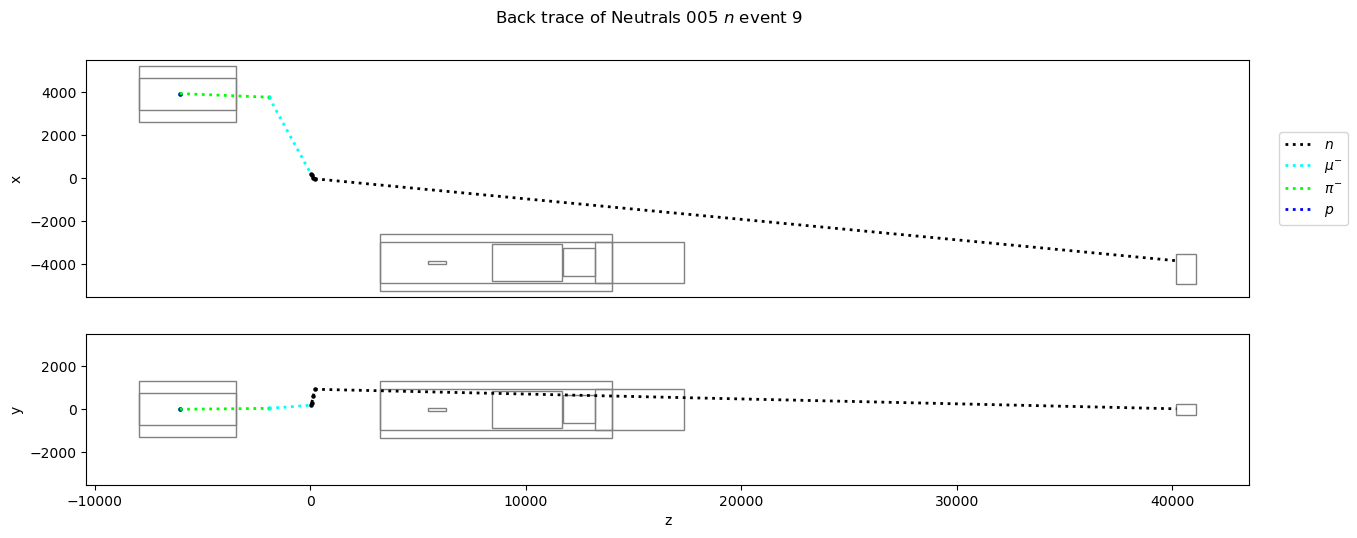

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           5
index                           39
time                 442996.452191
virtualdetectorId              101
creationCode                    97
pdgId                         2112
x                     -3856.169464
y                        20.989842
z                         40185.38
px                      -60.204652
py                       43.112134
pz                         21.2962
startx                  624.102015
starty                 -350.820937
startz                 -306.183272
startpx              -23030.511856
startpy               18667.196274
startpz                9672.886848
starttime               358.135132
E                         0.003159
r                        52.233453
weight                    55.07211
Name: 200, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,2349,Neutrals,5,39,294.790314,358.135132,56,2112,737.919563,223.129313,...,624.102015,-350.820937,-306.183272,-1.786674e+04,30383.666992,-4.627736e+04,-3.877959e+02,-53652.854919,1.389524e+04,1.799101e+03
1,2350,Neutrals,5,39,280.015137,295.369720,115,2112,811.244426,194.851151,...,734.622765,228.735753,-229.680599,-1.453770e+04,-5151.226997,-5.628635e+04,-1.786674e+04,30383.666992,-4.627736e+04,1.810813e+03
2,2351,Neutrals,5,39,36.847466,37.515327,14,13,910.257269,126.799978,...,811.244426,194.851151,28.913202,-6.951038e+04,32832.096100,4.769482e+04,-0.000000e+00,-0.000000,0.000000e+00,3.343917e+04
3,2352,Neutrals,5,39,-34.406048,36.847466,14,-211,3813.905280,35.386844,...,910.257269,126.799978,-8.468269,-6.196784e+04,-50636.379242,4.842890e+04,-6.034435e+04,45496.986389,3.127526e+04,2.844544e+04
4,2353,Neutrals,5,39,-35.236698,-34.406048,100,3112,3918.697199,1.228296,...,3813.905280,35.386844,-6233.405902,-6.923264e+05,293354.187012,-8.767415e+05,-7.193308e+05,157257.019043,-8.846485e+05,4.662611e+05
5,2354,Neutrals,5,39,-35.251472,-35.236698,101,-211,3920.387577,-0.614714,...,3918.697199,1.228296,-6100.769610,-6.116541e+05,662262.145996,-1.306777e+06,-6.144673e+05,654440.002441,-1.304462e+06,1.454123e+06
6,2355,Neutrals,5,39,-35.387901,-35.251472,56,2212,3929.977788,-0.686452,...,3920.387577,-0.614714,-6097.135584,-2.150417e+06,0.000000,-8.624852e+06,-2.049514e+06,35932.434082,-8.599878e+06,8.000000e+06


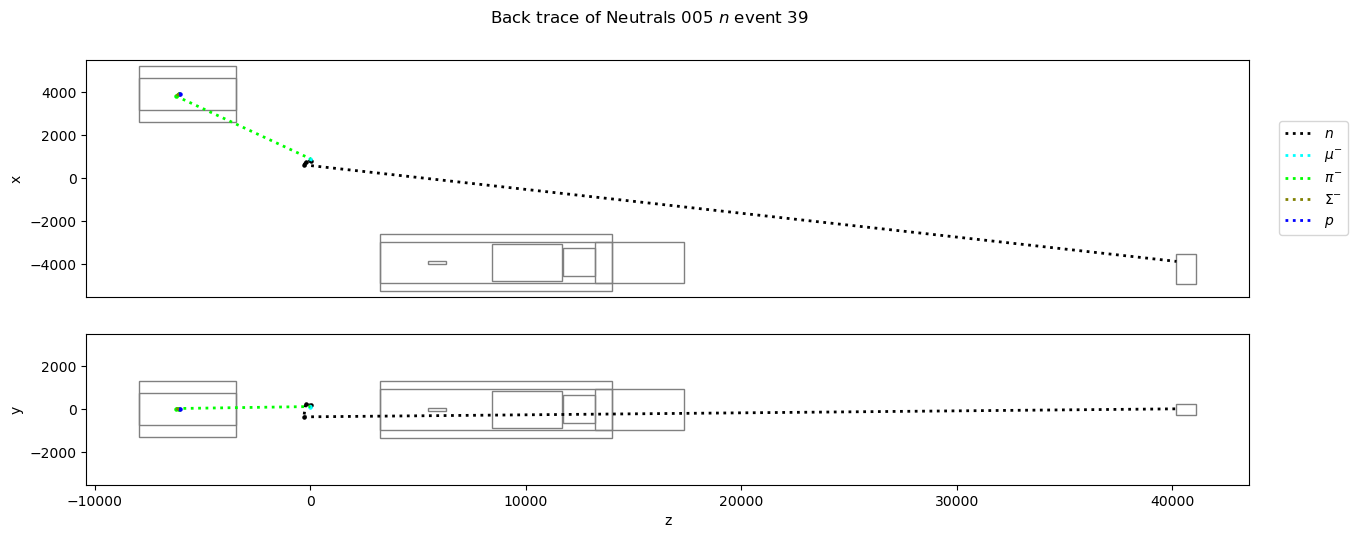

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          6
index                          14
time                  8336.418549
virtualdetectorId             101
creationCode                   56
pdgId                        2112
x                    -3879.871762
y                      -77.385519
z                        40185.38
px                   -1616.046611
py                    -272.159807
pz                    15953.97071
startx                 376.165868
starty                 308.914215
startz                  57.115935
startpx             -10474.137306
startpy              14350.922585
startpz              10814.188004
starttime              410.769012
E                      136.869736
r                       81.059795
weight                   55.07211
Name: 220, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,2612,Neutrals,6,14,244.950607,411.848663,115,2112,730.130282,190.289644,...,372.558590,313.856653,60.840326,2.564883e+04,16729.032516,-1.015450e+04,-1.047414e+04,14350.922585,1.081419e+04,5.537296e+02
1,2613,Neutrals,6,14,35.914398,143.664871,14,13,3930.923638,80.535360,...,730.130282,190.289644,71.983936,-3.403020e+04,-19834.709167,1.530529e+04,-0.000000e+00,0.000000,-0.000000e+00,8.137119e+03
2,2614,Neutrals,6,14,30.909414,35.914398,101,-211,3898.719636,0.703993,...,3930.923638,80.535360,-5931.806079,1.818250e+04,-118631.401062,2.874011e+04,-7.936259e+04,-50976.955414,3.372792e+04,4.673559e+04
3,2615,Neutrals,6,14,30.465595,30.909414,56,2212,3930.495750,-0.174007,...,3898.719636,0.703993,-6186.163258,-2.150417e+06,0.000000,-8.624852e+06,-2.059660e+06,65076.148987,-8.439879e+06,8.000000e+06


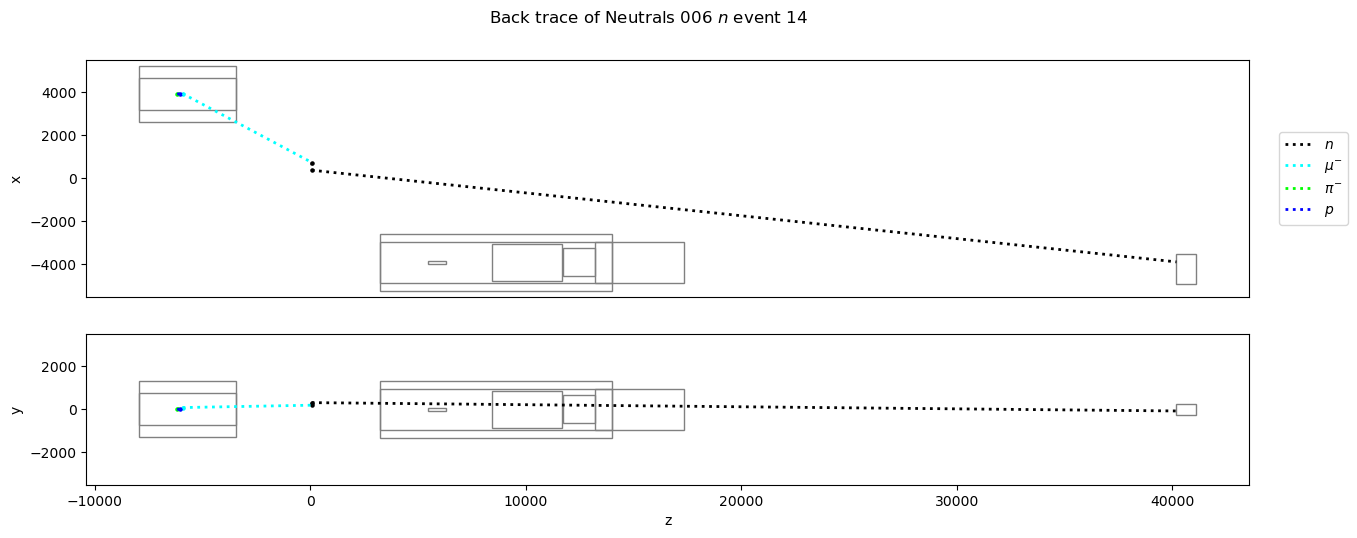

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           7
index                            0
time                 125802.901581
virtualdetectorId              101
creationCode                    56
pdgId                         2112
x                     -3859.448276
y                        87.999911
z                         40185.38
px                      -36.714365
py                      165.963886
pz                        39.87229
startx                 3915.807176
starty                 -783.796111
startz                -1819.742043
startpx              -20933.197021
startpy               -11149.37973
startpz                4272.123337
starttime               316.640869
E                         0.016221
r                        98.634884
weight                    55.07211
Name: 240, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,2868,Neutrals,7,0,143.751282,509.289398,97,2112,4219.520667,58.770903,...,2629.478006,-1468.917055,-1557.223285,2.108933e+04,11969.760895,2.110598e+04,-2.093320e+04,-11149.379730,4.272123e+03,5.498262e+02
1,2869,Neutrals,7,0,111.099747,143.751282,97,2112,3991.895455,150.558483,...,4219.520667,58.770903,-1979.316570,4.211063e+04,-14092.656136,4.091811e+04,5.750772e+03,18493.017197,-5.336563e+04,1.938366e+03
2,2870,Neutrals,7,0,51.960632,111.099747,101,2112,3881.655696,-1.267121,...,3991.895455,150.558483,-2096.798710,6.009217e+03,8276.079178,2.260963e+05,6.009217e+03,8276.079178,2.260963e+05,2.687513e+04
3,2871,Neutrals,7,0,51.312790,51.960632,56,2212,3929.760088,-0.798580,...,3881.655696,-1.267121,-6244.561393,-2.150417e+06,0.000000,-8.624852e+06,-2.127986e+06,6934.332848,-8.205207e+06,8.000000e+06


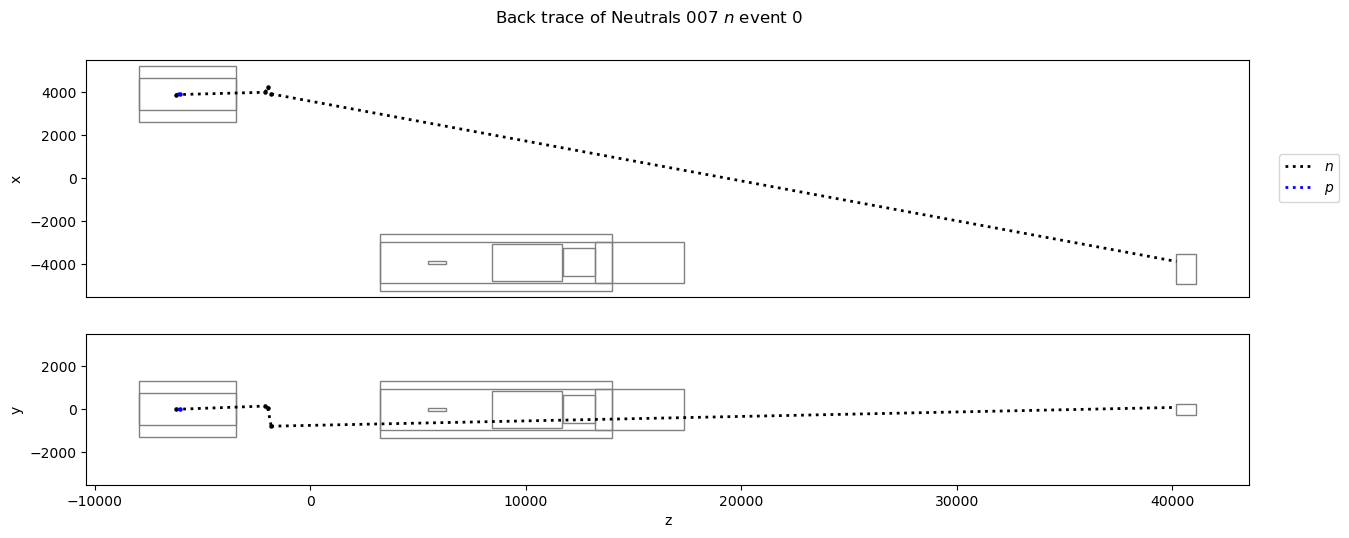

------------------------------------------------------------------------------


tag                        Neutrals
fileno                            7
index                            39
time                 2971063.014604
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3942.032809
y                         76.539299
z                          40185.38
px                         0.755236
py                        -6.585061
pz                        16.094875
startx                  -480.382568
starty                  -117.786646
startz                   843.224119
startpx                -9333.333969
startpy                 17919.26384
startpz                -8266.736984
starttime                160.271301
E                          0.000161
r                         85.467882
weight                     55.07211
Name: 260, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,3130,Neutrals,7,39,95.835007,160.271301,56,2112,-350.160534,2.870641,...,-480.382568,-117.786646,843.224119,-2.915983e+04,-16301.187515,3.591597e+04,3.276941e+04,10021.080971,3.091774e+04,1.279498e+03
1,3131,Neutrals,7,39,83.747185,96.709572,97,2112,-257.722034,32.344660,...,-358.286586,-1.672057,324.145688,8.673212e+03,47110.408783,1.436308e+04,-2.915983e+04,-16301.187515,3.591597e+04,1.329947e+03
2,3132,Neutrals,7,39,83.664467,83.747185,97,2112,-258.485579,31.576338,...,-257.722034,32.344660,187.123468,2.900511e+04,29186.519623,5.426078e+04,2.900511e+04,29186.519623,5.426078e+04,2.464601e+03
3,3133,Neutrals,7,39,78.716484,83.664467,78,2112,169.231340,190.043567,...,-258.485579,31.576338,185.695078,-2.899700e+05,-104110.778809,1.836739e+05,-2.902896e+05,-182475.204468,1.028860e+05,6.613879e+04
4,3134,Neutrals,7,39,30.440866,78.716484,101,-211,3911.737733,-1.635212,...,169.231340,190.043567,-80.159599,-1.781671e+04,97085.525513,1.217772e+05,-0.000000e+00,-0.000000,0.000000e+00,7.031684e+04
5,3135,Neutrals,7,39,30.201380,30.440866,56,2212,3928.944995,-1.773543,...,3911.737733,-1.635212,-6126.641929,-2.150417e+06,0.000000,-8.624852e+06,-2.165588e+06,42022.441864,-8.502549e+06,8.000000e+06


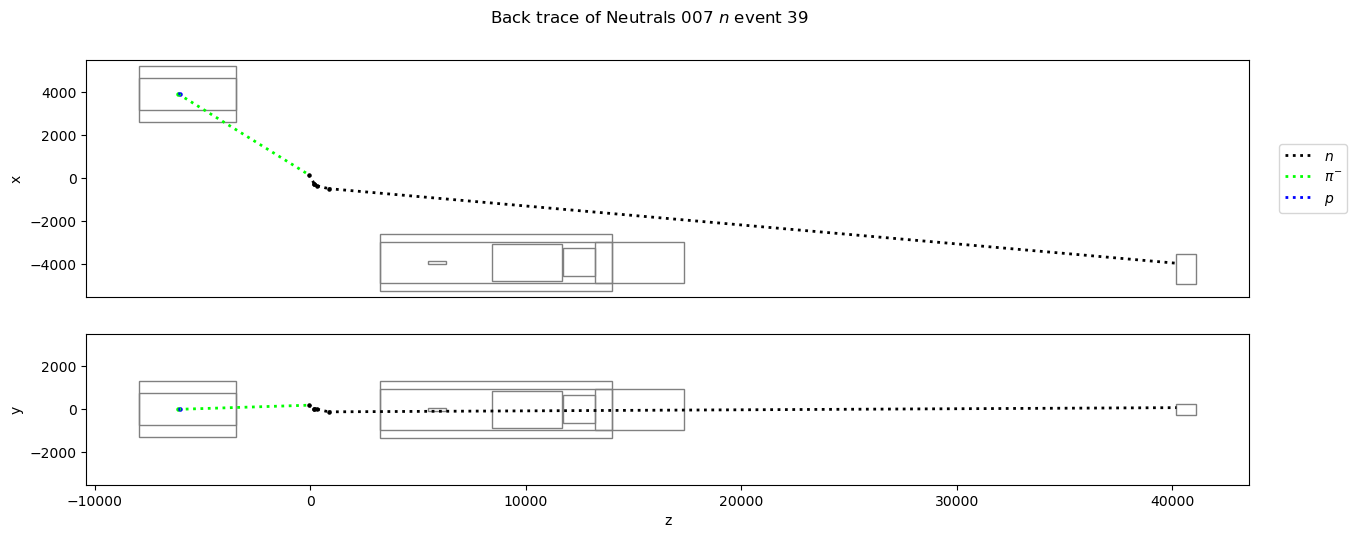

------------------------------------------------------------------------------


tag                        Neutrals
fileno                            8
index                            20
time                 7101941.244262
virtualdetectorId               101
creationCode                     97
pdgId                          2112
x                      -3904.073352
y                          98.74047
z                          40185.38
px                        -1.427843
py                        -4.570423
pz                         4.713365
startx                  2630.911131
starty                  -373.345796
startz                  -265.590152
startpx                 1625.172973
startpy               -14620.859146
startpz               -46583.812714
starttime                 53.666512
E                          0.000024
r                         98.740497
weight                     55.07211
Name: 280, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,3326,Neutrals,8,20,53.227161,53.666512,97,2112,2630.775361,-370.797640,...,2630.911131,-373.345796,-265.590152,9.721866e+02,-18246.171951,-8.000698e+04,9.721866e+02,-18246.171951,-8.000698e+04,3.577286e+03
1,3327,Neutrals,8,20,51.132011,53.227161,56,2112,2492.240877,-265.264652,...,2630.775361,-370.797640,-254.416834,2.158798e+05,-164453.231812,-3.996728e+04,2.158798e+05,-164453.231812,-3.996728e+04,3.922441e+04
2,3328,Neutrals,8,20,42.813526,51.316338,78,2112,2026.330348,241.156653,...,2504.428669,-274.549086,-231.025427,1.790200e+05,-202768.417358,-4.622784e+04,2.158798e+05,-164453.231812,-3.996728e+04,3.925192e+04
3,3329,Neutrals,8,20,1.110221,42.813526,14,-211,3921.062089,20.092873,...,2026.330348,241.156653,-112.655136,3.276175e+04,-24640.186310,8.963293e+04,-0.000000e+00,0.000000,-0.000000e+00,3.129341e+04
4,3330,Neutrals,8,20,0.638466,1.110221,14,3122,3909.388131,0.038451,...,3921.062089,20.092873,-6137.323532,9.338101e+04,160417.068481,2.514592e+04,9.338101e+04,160417.068481,2.514592e+04,1.561476e+04
5,3331,Neutrals,8,20,0.638466,0.638466,102,3212,3909.388131,0.038451,...,3909.388131,0.038451,-6140.467130,3.521983e+04,205613.952637,-4.660250e+03,3.521983e+04,205613.952637,-4.660250e+03,1.811572e+04
6,3332,Neutrals,8,20,0.607138,0.638466,101,3222,3911.629527,-0.297664,...,3909.388131,0.038451,-6140.467130,-4.070365e+05,63755.981445,-1.074963e+06,-3.757815e+05,34285.064697,-1.066872e+06,4.658912e+05
7,3333,Neutrals,8,20,0.342465,0.607138,56,2212,3930.904273,-0.697094,...,3911.629527,-0.297664,-6134.351987,-2.150417e+06,0.000000,-8.624852e+06,-2.114598e+06,41672.382355,-8.514816e+06,8.000000e+06


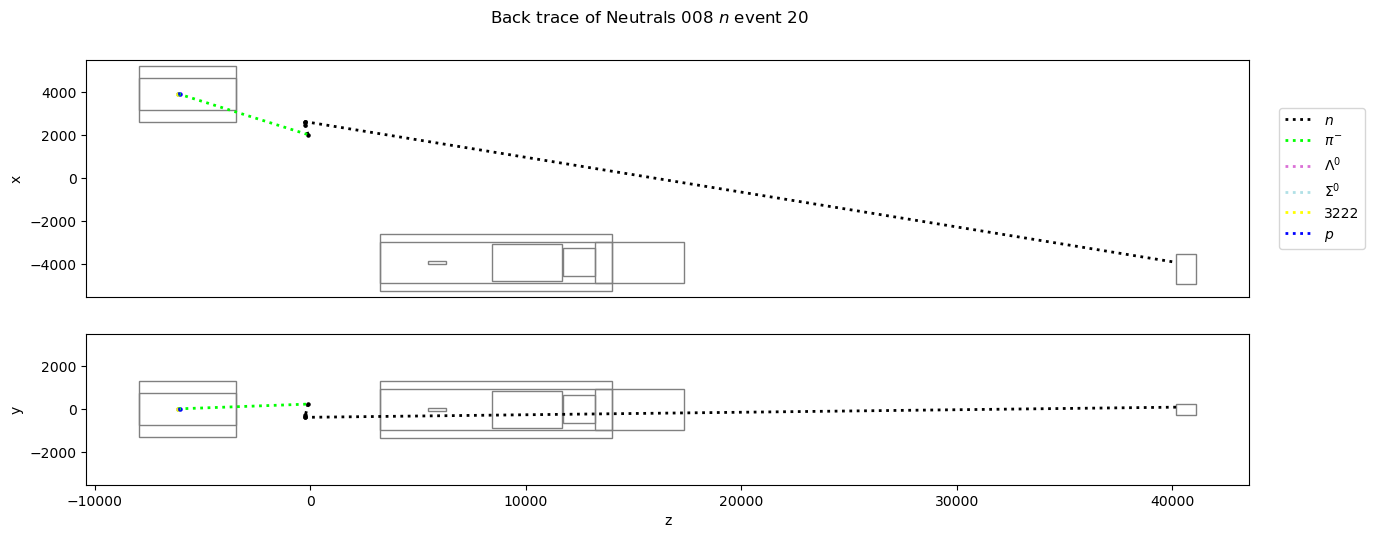

------------------------------------------------------------------------------


tag                      Neutrals
fileno                          8
index                          58
time                  6941.363187
virtualdetectorId             101
creationCode                   56
pdgId                        2112
x                    -3920.043213
y                       -9.826282
z                        40185.38
px                   -2109.353318
py                   -1001.772136
pz                   23430.623679
startx                -350.103557
starty                 313.084687
startz                  25.849587
startpx             -37182.495117
startpy               13434.71241
startpz                669.163823
starttime             1232.521973
E                      295.008755
r                       18.813306
weight                   55.07211
Name: 300, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,3563,Neutrals,8,58,1178.106567,1234.855225,115,2112,-5.323165,74.457681,...,-377.759976,323.077455,26.347313,-1.255427e+04,-26827.451706,2.795769e+04,-3.718250e+04,13434.712410,6.691638e+02,8.824162e+02
1,3564,Neutrals,8,58,87.732109,168.132401,14,13,3792.318672,6.546906,...,-5.323165,74.457681,-99.214101,3.070020e+03,-847.496152,2.417424e+04,-0.000000e+00,0.000000,0.000000e+00,2.776995e+03
2,3565,Neutrals,8,58,40.484905,87.732109,101,-211,3911.215094,-2.487505,...,3792.318672,6.546906,-2835.963585,6.678960e+04,95910.140991,-2.404697e+04,5.855783e+03,-38419.731140,4.615561e+04,4.405361e+04
3,3566,Neutrals,8,58,40.197941,40.484905,56,2212,3931.785410,-2.696023,...,3911.215094,-2.487505,-6141.097891,-2.150417e+06,0.000000,-8.624852e+06,-2.111574e+06,38837.677002,-8.506250e+06,8.000000e+06


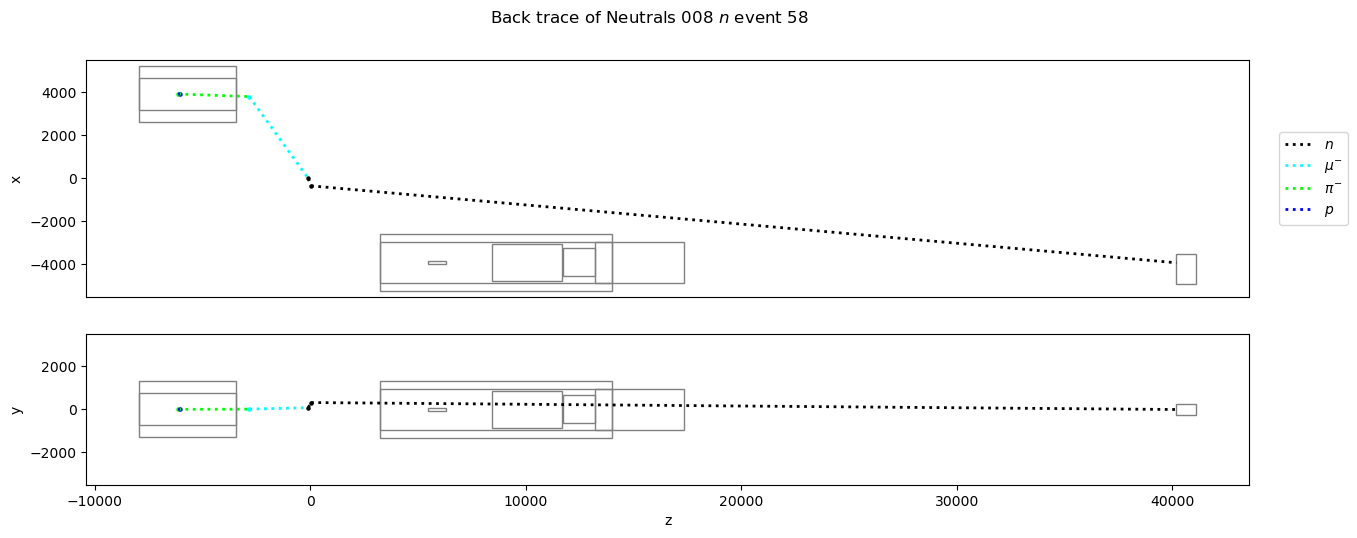

------------------------------------------------------------------------------


tag                       Neutrals
fileno                           9
index                           24
time                 155386.616115
virtualdetectorId              101
creationCode                    56
pdgId                         2112
x                     -3954.245665
y                       -69.381964
z                         40185.38
px                      -83.997044
py                      -46.932705
pz                      850.486737
startx                  534.356213
starty                  311.275741
startz                   42.398535
startpx               -2196.877003
startpy                4319.485188
startpz                 707.767069
starttime               672.703186
E                         0.389854
r                        85.664951
weight                    55.07211
Name: 320, dtype: object

,level_0,tag,fileno,index,starttime,endtime,creationCode,pdgId,startx,starty,...,endx,endy,endz,startpx,startpy,startpz,endpx,endpy,endpz,E
0,3825,Neutrals,9,24,84.839226,679.865967,97,2112,828.775687,-86.724418,...,529.335395,321.147640,44.016089,-1.421731e+03,-7491.580009,-5.333422e+02,-2.196877e+03,4319.485188,7.077671e+02,3.109341e+01
1,3826,Neutrals,9,24,72.302284,84.839226,97,2112,811.868318,-42.679714,...,828.775687,-86.724418,82.998672,3.320147e+04,-26061.445236,-1.576266e+04,-1.048949e+02,-13125.954628,-4.150382e+04,1.079666e+03
2,3827,Neutrals,9,24,60.117626,72.302284,115,2112,843.848425,202.695075,...,811.868318,-42.679714,232.542231,-2.270032e+04,-33202.533722,8.288219e+04,5.527632e+03,-57810.478210,7.099422e+04,4.505737e+03
3,3828,Neutrals,9,24,-35.720074,-2.536033,14,13,3890.586855,-5.375498,...,843.848425,202.695075,-13.744505,-4.907804e+04,3925.203323,7.942701e+04,-0.000000e+00,0.000000,-0.000000e+00,3.539624e+04
4,3829,Neutrals,9,24,-55.566395,-35.720074,101,-211,3917.959721,0.689022,...,3890.586855,-5.375498,-3894.764974,-6.746581e+04,25525.213242,5.053422e+04,-4.665240e+04,-14889.751434,6.843858e+04,2.546531e+04
5,3830,Neutrals,9,24,-55.756298,-55.566395,56,2212,3931.910401,0.604371,...,3917.959721,0.689022,-6112.960292,-2.150417e+06,0.000000,-8.624852e+06,-2.185741e+06,13921.264648,-8.544600e+06,8.000000e+06


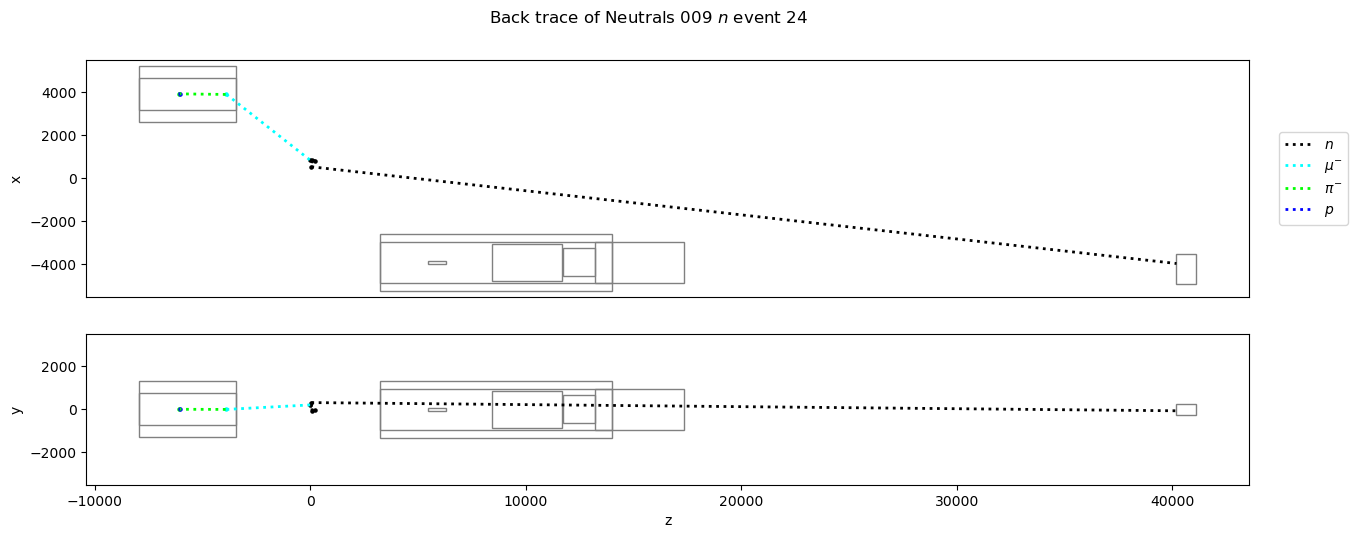

In [6]:
for pdgId in list_of_pdgId:
    mydf = df_particles.query("pdgId==%i"%(pdgId)).reset_index(drop=True)
    for ii in range(0, len(mydf), 20):
        print('------------------------------------------------------------------------------')
        df_ = mydf.iloc[ii]
        tag, fileno, index = df_['tag'], df_['fileno'], df_['index']
        dfg_ = df_genealogy.query("tag==@tag and fileno==@fileno and index==@index").reset_index()
        display(df_)
        display(dfg_)
        fig, ax_top, ax_side = plot_utils.draw_particle_event_backtrace(mydf, df_genealogy, tag, fileno, index)
        plt.show()

source count
$\gamma$ :  4


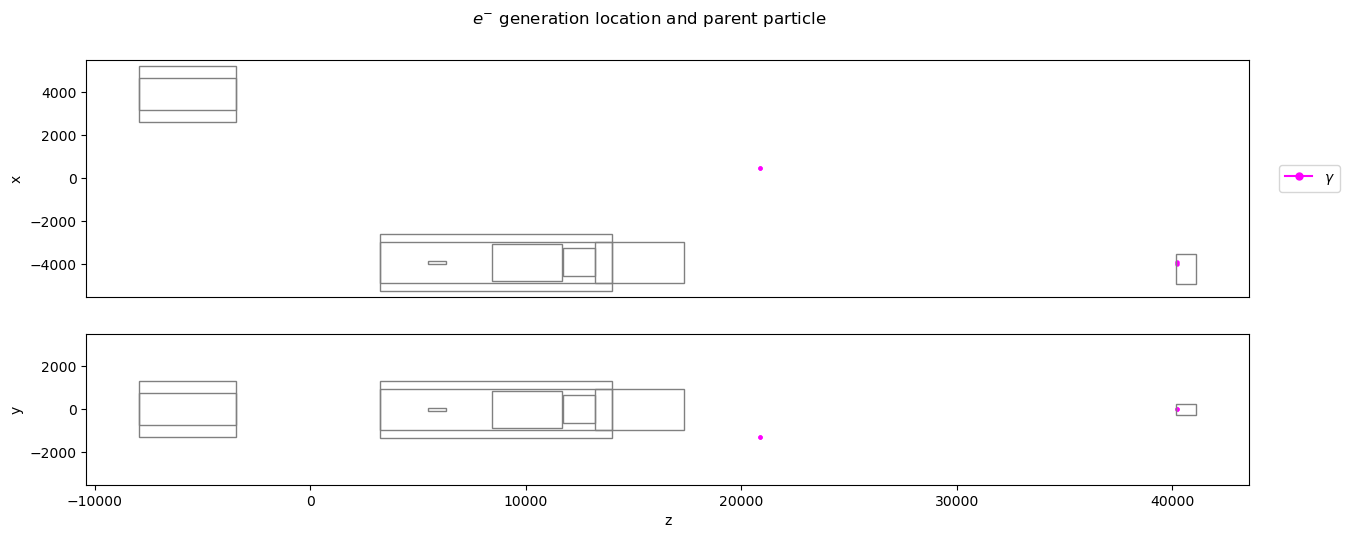

source count
$n$ :  257
1000751879 :  5
1000260569 :  3
$e^{+}$ :  27
$e^{-}$ :  22
1000140289 :  1
1000210489 :  1
1000120249 :  4
$\mu^{-}$ :  2
1000220489 :  1
1000240529 :  1


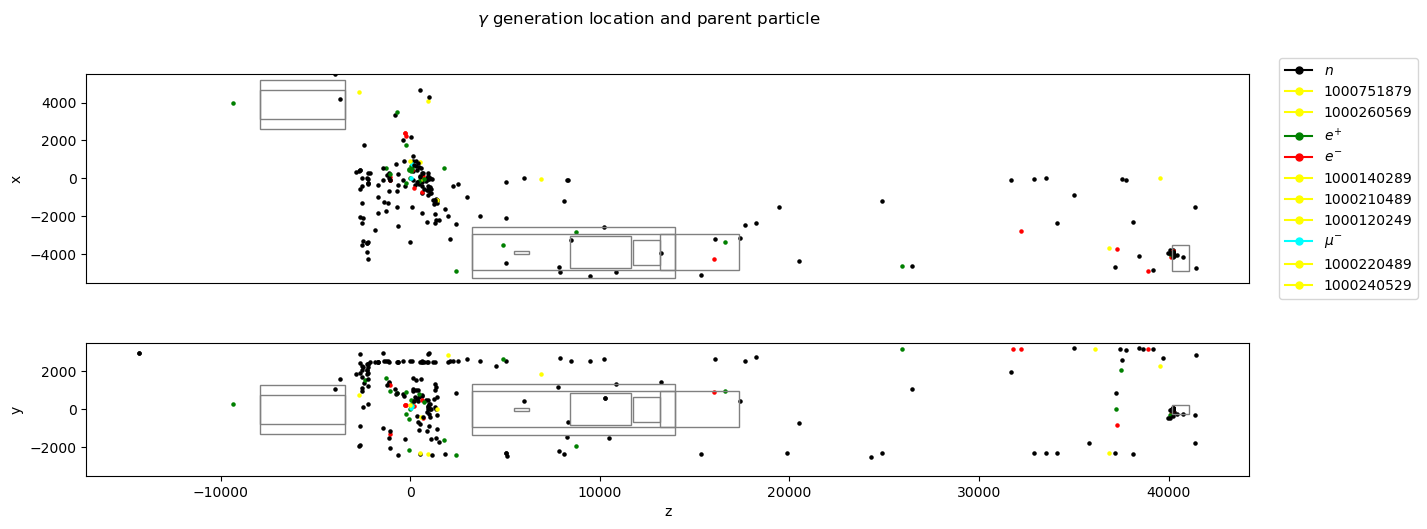

source count
$\mu^{-}$ :  148
$\pi^{-}$ :  109
$p$ :  65
$\pi^{+}$ :  7
$\gamma$ :  9
$K^{0}_{S}$ :  1


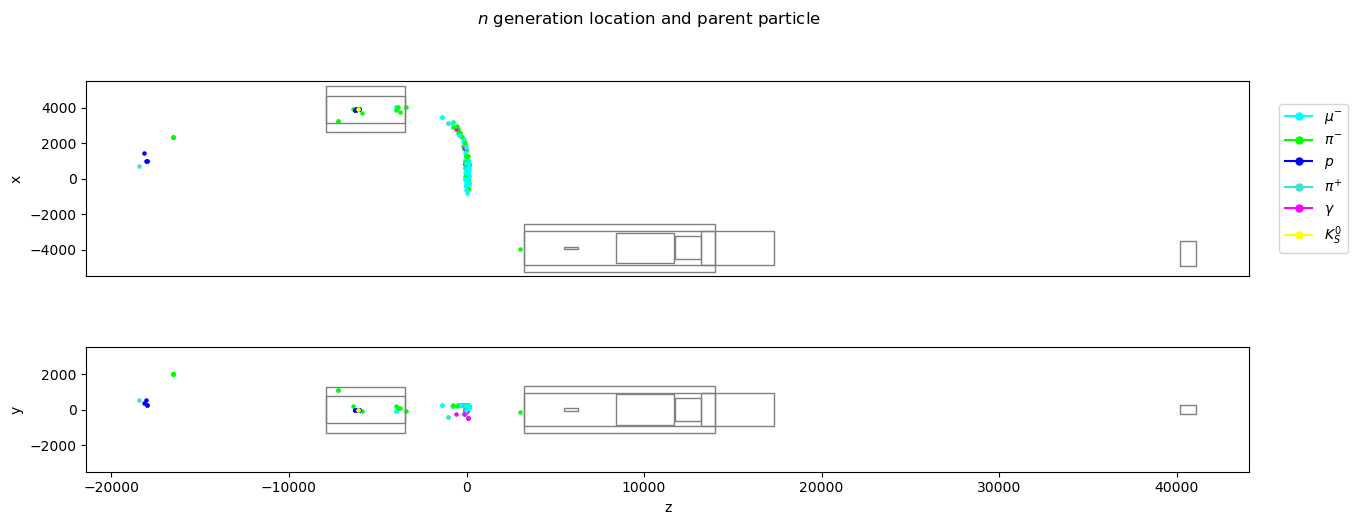

In [3]:
list_of_pdgId = np.sort(df_particles['pdgId'].unique())
df_sources = []
for pdgId in list_of_pdgId:
    mydf = df_particles.query("pdgId==%i"%(pdgId)).reset_index(drop=True)
    dfs_, fig, ax_top, ax_side = plot_utils.draw_neutron_source_all(mydf, df_genealogy, pdgid_dict[pdgId]+" generation location and parent particle")
    df_sources.append(dfs_)
    plt.show()

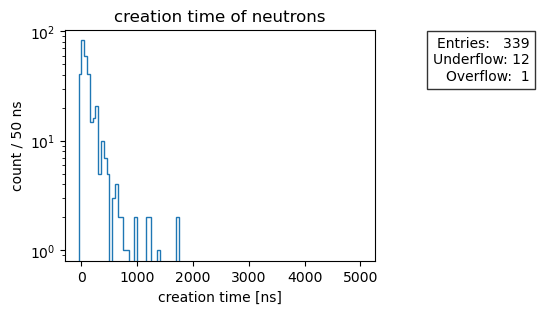

In [4]:
ybins = np.linspace(-50., 5000., 102)
mydf = df_sources[list_of_pdgId.tolist().index(2112)]
fig, ax = plt.subplots(figsize=(4,3))
counts, bin_edges, _ = ax.hist(mydf['starttime'], ybins, histtype='step')
ax.set_title('creation time of neutrons')
ax.set_xlabel('creation time [ns]')
ax.set_ylabel('count / 50 ns')
entries = len(mydf['starttime'])
mean = np.mean(mydf['starttime'])
std = np.std(mydf['starttime'])
underflow = (mydf['starttime'] < -50.).sum()
overflow  = (mydf['starttime'] > 5000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    #f"Mean:      {mean:.3f}\n"
    #f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
ax.set_yscale('log')


Text(1.5, 0.97, 'Entries:   254\nMean:      14925.936\nStd Dev:   23301.177\nUnderflow: 0\nOverflow:  62')

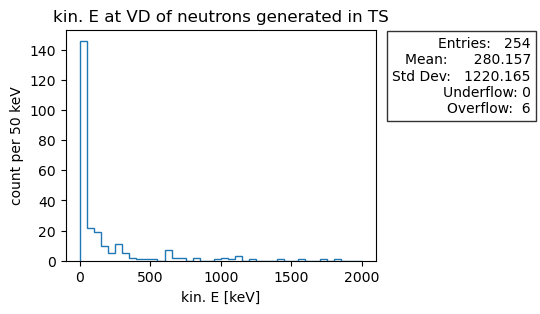

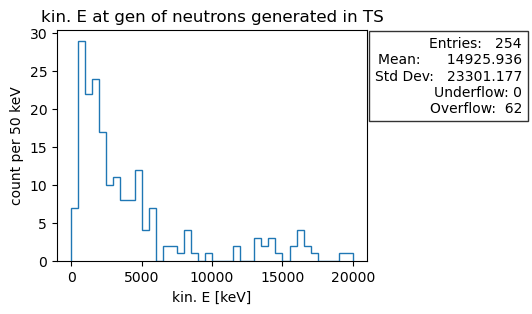

In [7]:
ybins = np.linspace(0., 2000., 41)
mydf1 = mydf.query("z>-2000 and z<1000").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(4,3))
ax.hist(mydf1['EatVD'], ybins, histtype='step')
ax.set_title('kin. E at VD of neutrons generated in TS')
ax.set_xlabel('kin. E [keV]')
ax.set_ylabel('count per 50 keV')
entries = len(mydf1['EatVD'])
mean = np.mean(mydf1['EatVD'])
std = np.std(mydf1['EatVD'])
underflow = (mydf1['EatVD'] < 0.).sum()
overflow  = (mydf1['EatVD'] > 2000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    f"Mean:      {mean:.3f}\n"
    f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

ybins = np.linspace(0., 20000., 41)
fig, ax = plt.subplots(figsize=(4,3))
ax.hist(mydf1['startE'], ybins, histtype='step')
ax.set_title('kin. E at gen of neutrons generated in TS')
ax.set_xlabel('kin. E [keV]')
ax.set_ylabel('count per 50 keV')
entries = len(mydf1['startE'])
mean = np.mean(mydf1['startE'])
std = np.std(mydf1['startE'])
underflow = (mydf1['startE'] < 0.).sum()
overflow  = (mydf1['startE'] > 20000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    f"Mean:      {mean:.3f}\n"
    f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)